# Project 1: California Housing Prices — Regression Analysis
**Dataset Source:** https://www.kaggle.com/datasets/camnugent/california-housing-prices

**Pipeline:**
1. Data Download & Loading
2. Data Cleaning
3. EDA + Statistical Analysis
4. Feature Selection
5. ML Models & Evaluation

In [1]:
import os
import urllib.request
import pandas as pd

In [2]:
# Download the dataset
DATA_URL = "https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.csv"
DATA_PATH = "housing.csv"

if not os.path.exists(DATA_PATH):
    print("Downloading data...")
    urllib.request.urlretrieve(DATA_URL, DATA_PATH)
    print(f"Saved to {DATA_PATH}")
else:
    print("Data already downloaded.")

Data already downloaded.


In [3]:
df = pd.read_csv(DATA_PATH)
print(f"Shape: {df.shape}")
df.head()

Shape: (20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


---
## Chunk 1: Data Cleaning

**Steps:**
1. Shape, dtypes, and first look
2. Missing values analysis
3. Duplicate check
4. Statistical summary
5. Data type fixes
6. Outlier detection (IQR + visual)
7. Handle missing values (grouped median imputation)
8. Handle outliers (drop census cap + Winsorize)
9. Log transform for skewed columns
10. Final cleaned dataset

### Step 1 — Shape, Data Types & First Look

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.float_format", lambda x: f"{x:.2f}")

print("=" * 50)
print(f"Dataset Shape : {df.shape[0]} rows x {df.shape[1]} columns")
print("=" * 50)
print("\nColumn Data Types:")
print(df.dtypes)
print("\nFirst 5 rows:")
df.head()

Dataset Shape : 20640 rows x 10 columns

Column Data Types:
longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity        object
dtype: object

First 5 rows:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.00,880.00,129.00,322.00,126.00,8.33,452600.00,NEAR BAY
1,-122.22,37.86,21.00,7099.00,1106.00,2401.00,1138.00,8.30,358500.00,NEAR BAY
2,-122.24,37.85,52.00,1467.00,190.00,496.00,177.00,7.26,352100.00,NEAR BAY
3,-122.25,37.85,52.00,1274.00,235.00,558.00,219.00,5.64,341300.00,NEAR BAY
4,-122.25,37.85,52.00,1627.00,280.00,565.00,259.00,3.85,342200.00,NEAR BAY


### Step 2 — Missing Values Analysis

Missing Values Summary:
                Missing Count  Missing %
total_bedrooms            207       1.00


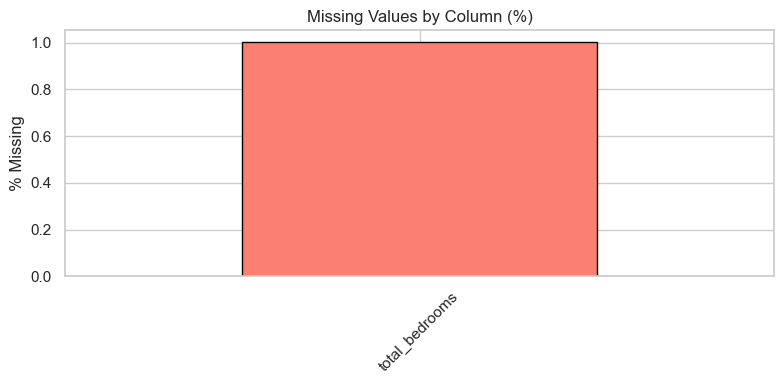

In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_pct
}).sort_values("Missing %", ascending=False)

print("Missing Values Summary:")
print(missing_df[missing_df["Missing Count"] > 0])

# Visualize
fig, ax = plt.subplots(figsize=(8, 4))
missing_df[missing_df["Missing Count"] > 0]["Missing %"].plot(
    kind="bar", ax=ax, color="salmon", edgecolor="black"
)
ax.set_title("Missing Values by Column (%)")
ax.set_ylabel("% Missing")
ax.set_xlabel("")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Step 3 — Duplicate Check

In [6]:
n_duplicates = df.duplicated().sum()
print(f"Duplicate rows: {n_duplicates}")

if n_duplicates > 0:
    print("Dropping duplicates...")
    df = df.drop_duplicates()
    print(f"Shape after dropping duplicates: {df.shape}")
else:
    print("No duplicates found — no action needed.")

Duplicate rows: 0
No duplicates found — no action needed.


### Step 4 — Statistical Summary

In [7]:
num_only = df.select_dtypes(include=[np.number])

print("Numerical columns — descriptive statistics:")
num_only.describe().T.assign(
    skewness=num_only.skew(),
    kurtosis=num_only.kurt()
)

Numerical columns — descriptive statistics:


,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
longitude,20640.00,-119.57,2.00,-124.35,-121.80,-118.49,-118.01,-114.31,-0.30,-1.33
latitude,20640.00,35.63,2.14,32.54,33.93,34.26,37.71,41.95,0.47,-1.12
housing_median_age,20640.00,28.64,12.59,1.00,18.00,29.00,37.00,52.00,0.06,-0.80
total_rooms,20640.00,2635.76,2181.62,2.00,1447.75,2127.00,3148.00,39320.00,4.15,32.63
total_bedrooms,20433.00,537.87,421.39,1.00,296.00,435.00,647.00,6445.00,3.46,21.99
population,20640.00,1425.48,1132.46,3.00,787.00,1166.00,1725.00,35682.00,4.94,73.55
households,20640.00,499.54,382.33,1.00,280.00,409.00,605.00,6082.00,3.41,22.06
median_income,20640.00,3.87,1.90,0.50,2.56,3.53,4.74,15.00,1.65,4.95
median_house_value,20640.00,206855.82,115395.62,14999.00,119600.00,179700.00,264725.00,500001.00,0.98,0.33


In [8]:
print("Categorical column — ocean_proximity value counts:")
print(df["ocean_proximity"].value_counts())
print()
print("Value counts (%):")
print(df["ocean_proximity"].value_counts(normalize=True).mul(100).round(2).astype(str) + "%")

Categorical column — ocean_proximity value counts:
ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

Value counts (%):
ocean_proximity
<1H OCEAN     44.26%
INLAND        31.74%
NEAR OCEAN    12.88%
NEAR BAY      11.09%
ISLAND         0.02%
Name: proportion, dtype: object


### Step 5 — Data Type Fixes

In [9]:
# ocean_proximity is already a string — convert to proper categorical type
df["ocean_proximity"] = df["ocean_proximity"].astype("category")

# housing_median_age and median_house_value should be float (already are, just confirming)
print("Updated dtypes:")
print(df.dtypes)
print(f"\nocean_proximity categories: {list(df['ocean_proximity'].cat.categories)}")

Updated dtypes:
longitude              float64
latitude               float64
housing_median_age     float64
total_rooms            float64
total_bedrooms         float64
population             float64
households             float64
median_income          float64
median_house_value     float64
ocean_proximity       category
dtype: object

ocean_proximity categories: ['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN']


### Step 6 — Outlier Detection (IQR Method + Visuals)

We use the **IQR (Interquartile Range)** method:
- Lower bound = Q1 - 1.5 × IQR
- Upper bound = Q3 + 1.5 × IQR
- Any value outside these bounds is flagged as an outlier

In [10]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

outlier_summary = []
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary.append({
        "Column": col, "Q1": Q1, "Q3": Q3,
        "IQR": IQR, "Lower Bound": lower, "Upper Bound": upper,
        "Outlier Count": n_outliers,
        "Outlier %": round(n_outliers / len(df) * 100, 2)
    })

outlier_df = pd.DataFrame(outlier_summary).set_index("Column")
print("Outlier Detection Summary (IQR Method):")
outlier_df

Outlier Detection Summary (IQR Method):


,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier %
Column,,,,,,,
longitude,-121.80,-118.01,3.79,-127.48,-112.33,0,0.00
latitude,33.93,37.71,3.78,28.26,43.38,0,0.00
housing_median_age,18.00,37.00,19.00,-10.50,65.50,0,0.00
total_rooms,1447.75,3148.00,1700.25,-1102.62,5698.38,1287,6.24
total_bedrooms,296.00,647.00,351.00,-230.50,1173.50,1271,6.16
population,787.00,1725.00,938.00,-620.00,3132.00,1196,5.79
households,280.00,605.00,325.00,-207.50,1092.50,1220,5.91
median_income,2.56,4.74,2.18,-0.71,8.01,681,3.30
median_house_value,119600.00,264725.00,145125.00,-98087.50,482412.50,1071,5.19


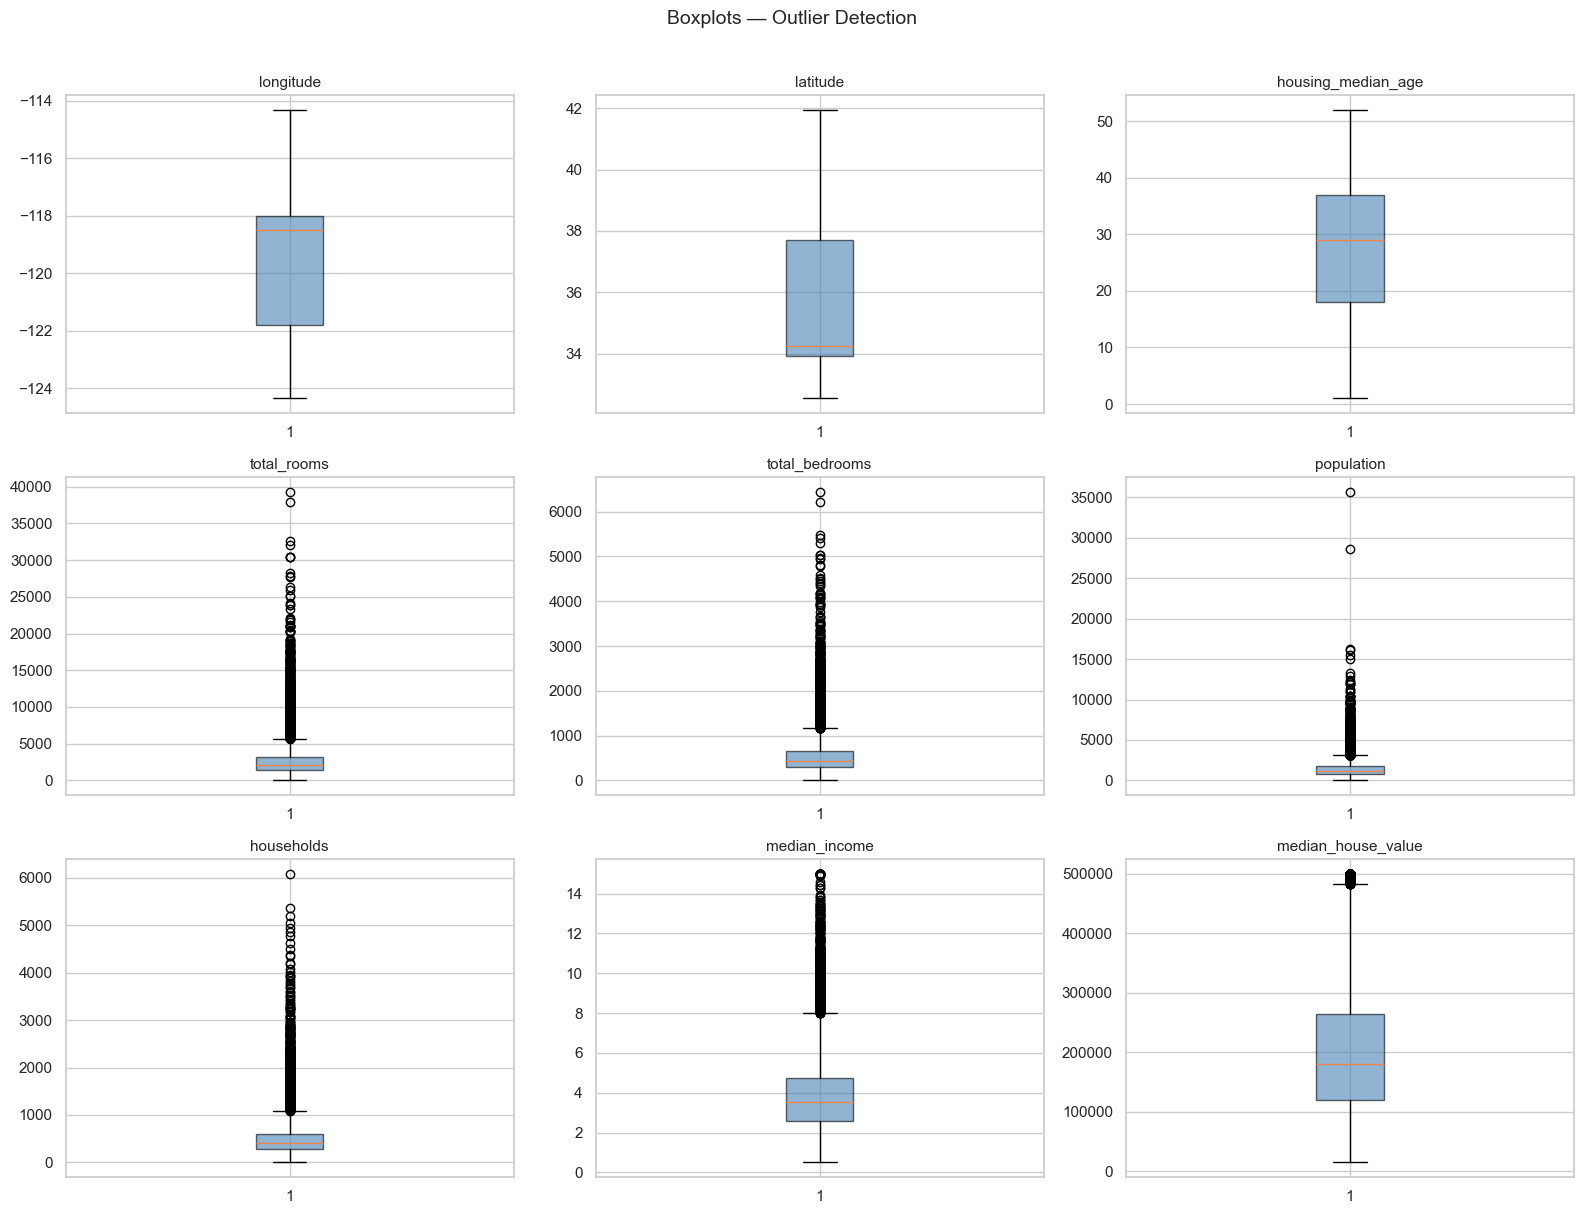

In [11]:
# Boxplots for all numerical columns
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor="steelblue", alpha=0.6))
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel("")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Boxplots — Outlier Detection", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### Step 7 — Handle Missing Values (Grouped Median Imputation)

**Why NOT global median imputation?**
Global median assumes every missing district looks like the *average* district — that's statistically incorrect.
`total_bedrooms` is structurally different across location types: a coastal district and an inland district have very different bedroom counts, so using a single global median mixes these populations.

**Research-quality approach — Grouped Median Imputation:**
1. Check correlation of `total_bedrooms` with all other numerical columns → find the most informative variable
2. Use `ocean_proximity` (best categorical grouping variable) to split districts into meaningful groups
3. Compute median of `total_bedrooms` **within each group separately**
4. Fill each missing value with the median of its own group

> **Titanic analogy (same logic):** Filling missing `Age` with the global median ignores that a "Master" (boy) and "Mr" (adult male) have completely different age distributions. We split by title and impute within each group. Here we split by `ocean_proximity` for the same reason — each location type represents a structurally different housing market.

Correlation of total_bedrooms with other numerical columns:
households            0.98
total_rooms           0.93
population            0.88
longitude             0.07
median_house_value    0.05
median_income        -0.01
latitude             -0.07
housing_median_age   -0.32
Name: total_bedrooms, dtype: float64


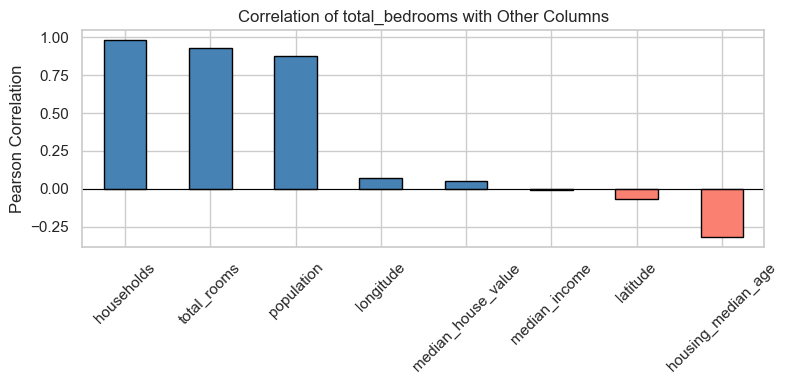

In [12]:
# --- Step 7a: Correlation of total_bedrooms with all numerical columns ---
corr_with_bedrooms = df.select_dtypes(include=[np.number]).corr()["total_bedrooms"].drop("total_bedrooms").sort_values(ascending=False)

print("Correlation of total_bedrooms with other numerical columns:")
print(corr_with_bedrooms.round(3))

fig, ax = plt.subplots(figsize=(8, 4))
corr_with_bedrooms.plot(kind="bar", ax=ax, color=["steelblue" if v > 0 else "salmon" for v in corr_with_bedrooms], edgecolor="black")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Correlation of total_bedrooms with Other Columns")
ax.set_ylabel("Pearson Correlation")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
# --- Step 7b: Grouped median of total_bedrooms by ocean_proximity ---
group_medians = df.groupby("ocean_proximity")["total_bedrooms"].median()
print("Median total_bedrooms per ocean_proximity group:")
print(group_medians)
print()

# Show how much these differ from the global median
global_median = df["total_bedrooms"].median()
print(f"Global median (what we would have used before): {global_median}")
print("\nDifference from global median per group:")
print((group_medians - global_median).round(1))

Median total_bedrooms per ocean_proximity group:
ocean_proximity
<1H OCEAN    438.00
INLAND       423.00
ISLAND       512.00
NEAR BAY     423.00
NEAR OCEAN   464.00
Name: total_bedrooms, dtype: float64

Global median (what we would have used before): 435.0

Difference from global median per group:
ocean_proximity
<1H OCEAN      3.00
INLAND       -12.00
ISLAND        77.00
NEAR BAY     -12.00
NEAR OCEAN    29.00
Name: total_bedrooms, dtype: float64


/var/folders/mw/jbc41xx11gq3v2wqc8yz62400000gn/T/ipykernel_23285/1418500921.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_medians = df.groupby("ocean_proximity")["total_bedrooms"].median()


In [14]:
# --- Step 7c: Fill missing values using group median ---
before = df["total_bedrooms"].isnull().sum()

df["total_bedrooms"] = df.groupby("ocean_proximity")["total_bedrooms"].transform(
    lambda x: x.fillna(x.median())
)

after = df["total_bedrooms"].isnull().sum()
print(f"total_bedrooms — missing before: {before}  |  after: {after}")
print(f"\nRemaining missing values across all columns: {df.isnull().sum().sum()}")

total_bedrooms — missing before: 207  |  after: 0

Remaining missing values across all columns: 0


/var/folders/mw/jbc41xx11gq3v2wqc8yz62400000gn/T/ipykernel_23285/3745518245.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df["total_bedrooms"] = df.groupby("ocean_proximity")["total_bedrooms"].transform(


### Step 8 — Handle Outliers (Drop Census Cap + Winsorize)

**Strategy A — Drop:** Only for `median_house_value >= $500,001`
This is a known **data artifact** (US census cut-off), not a real house price. Keeping it would teach the model a false ceiling.

**Strategy B — Winsorize (clip to IQR bounds):** For all other numerical columns.
Winsorization caps extreme values at the IQR boundary instead of removing the row entirely.

```
lower = Q1 - 1.5 × IQR
upper = Q3 + 1.5 × IQR
Any value below lower → replaced with lower
Any value above upper → replaced with upper
Everything in between → untouched
```

**Why Winsorize instead of drop?**
Outliers in housing data are real neighborhoods — a district with 39,000 rooms is a real dense urban area, not a data entry error. Dropping it loses all its other information (income, location, house price). Capping it lets the model still learn from that district, just with a bounded influence.

**Does Winsorization change model results?**

| Model Type | Impact | Why |
|---|---|---|
| Linear Regression, Ridge, Lasso | **High** | Squared loss punishes outliers exponentially — one extreme point can pull the entire regression line |
| Random Forest, XGBoost, LightGBM | **Low** | Tree splits on thresholds, not values — whether a value is 39,000 or 5,698, it goes to the same branch |
| KNN, SVM (RBF kernel) | **High** | Distance-based — extreme values dominate distance calculations |
| After log transform | **Reduced for all** | Log already compressed the extremes significantly before Winsorization kicks in |

> **Key insight:** Since we apply log transform AFTER Winsorization (Step 9), both work together. Winsorize first removes the worst extremes, then log transform smooths the remaining skew. For tree models, you can skip Winsorization entirely — it won't hurt but it won't help either.

In [15]:
# Drop rows where median_house_value is at the census cap ($500,001)
cap_mask = df["median_house_value"] >= 500001
print(f"Rows at $500,001 census cap (data artifact): {cap_mask.sum()} — dropping")
df = df[~cap_mask].copy()
print(f"Shape after removing capped target rows: {df.shape}")

Rows at $500,001 census cap (data artifact): 965 — dropping
Shape after removing capped target rows: (19675, 10)


In [16]:
# Winsorize all other numerical columns (clip to IQR bounds)
cols_to_winsorize = [c for c in num_cols if c != "median_house_value"]

for col in cols_to_winsorize:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    before = ((df[col] < lower) | (df[col] > upper)).sum()
    df[col] = df[col].clip(lower=lower, upper=upper)
    print(f"{col:25s} → {before} outliers capped")

print(f"\nFinal shape after all cleaning: {df.shape}")

longitude                 → 0 outliers capped
latitude                  → 0 outliers capped
housing_median_age        → 0 outliers capped
total_rooms               → 1251 outliers capped
total_bedrooms            → 1244 outliers capped
population                → 1126 outliers capped
households                → 1165 outliers capped
median_income             → 364 outliers capped

Final shape after all cleaning: (19675, 10)


### Step 9 — Log Transform for Skewed Columns

**Why log transform — not scaling?**

This is a common confusion worth locking in:

| Technique | What it changes | Does it fix skewness? |
|-----------|----------------|----------------------|
| StandardScaler | Mean → 0, Std → 1 | ❌ No — only rescales the axis |
| MinMaxScaler | Range → [0, 1] | ❌ No — same shape, different scale |
| **Log Transform** | Compresses large values, expands small ones | ✅ Yes — changes the actual distribution shape |

**Intuition:** If a column has values `[10, 100, 1000, 10000]`, scaling shifts and squeezes the numbers but the gap between 1000 and 10000 is still massive relative to 10 and 100. Log transform converts this to `[1, 2, 3, 4]` — equal spacing, symmetric distribution.

**Which columns need log transform?**
From Step 4, skewness > 1.0 flags a problematic right skew:
- `total_rooms` → skewness ~4.1
- `total_bedrooms` → skewness ~3.5
- `population` → skewness ~4.9
- `households` → skewness ~3.4
- `median_income` → skewness ~1.6
- `median_house_value` (target) → skewness ~1.0

**Formula used: `log1p(x)` = log(x + 1)**
We use `log1p` instead of `log` to safely handle any zero values (log(0) is undefined).

**When does this matter?**
- **Linear models (Ridge, Lasso, Linear Regression):** Log transform significantly improves performance — these models assume a linear relationship, and log-transforming a skewed feature can reveal it.
- **Tree-based models (Random Forest, XGBoost):** Do NOT need this — they split on thresholds, not distances. The distribution shape is irrelevant.
- **We apply it now** during cleaning so the cleaned dataset is model-ready. We will note which columns were transformed for inverse-transform during prediction.

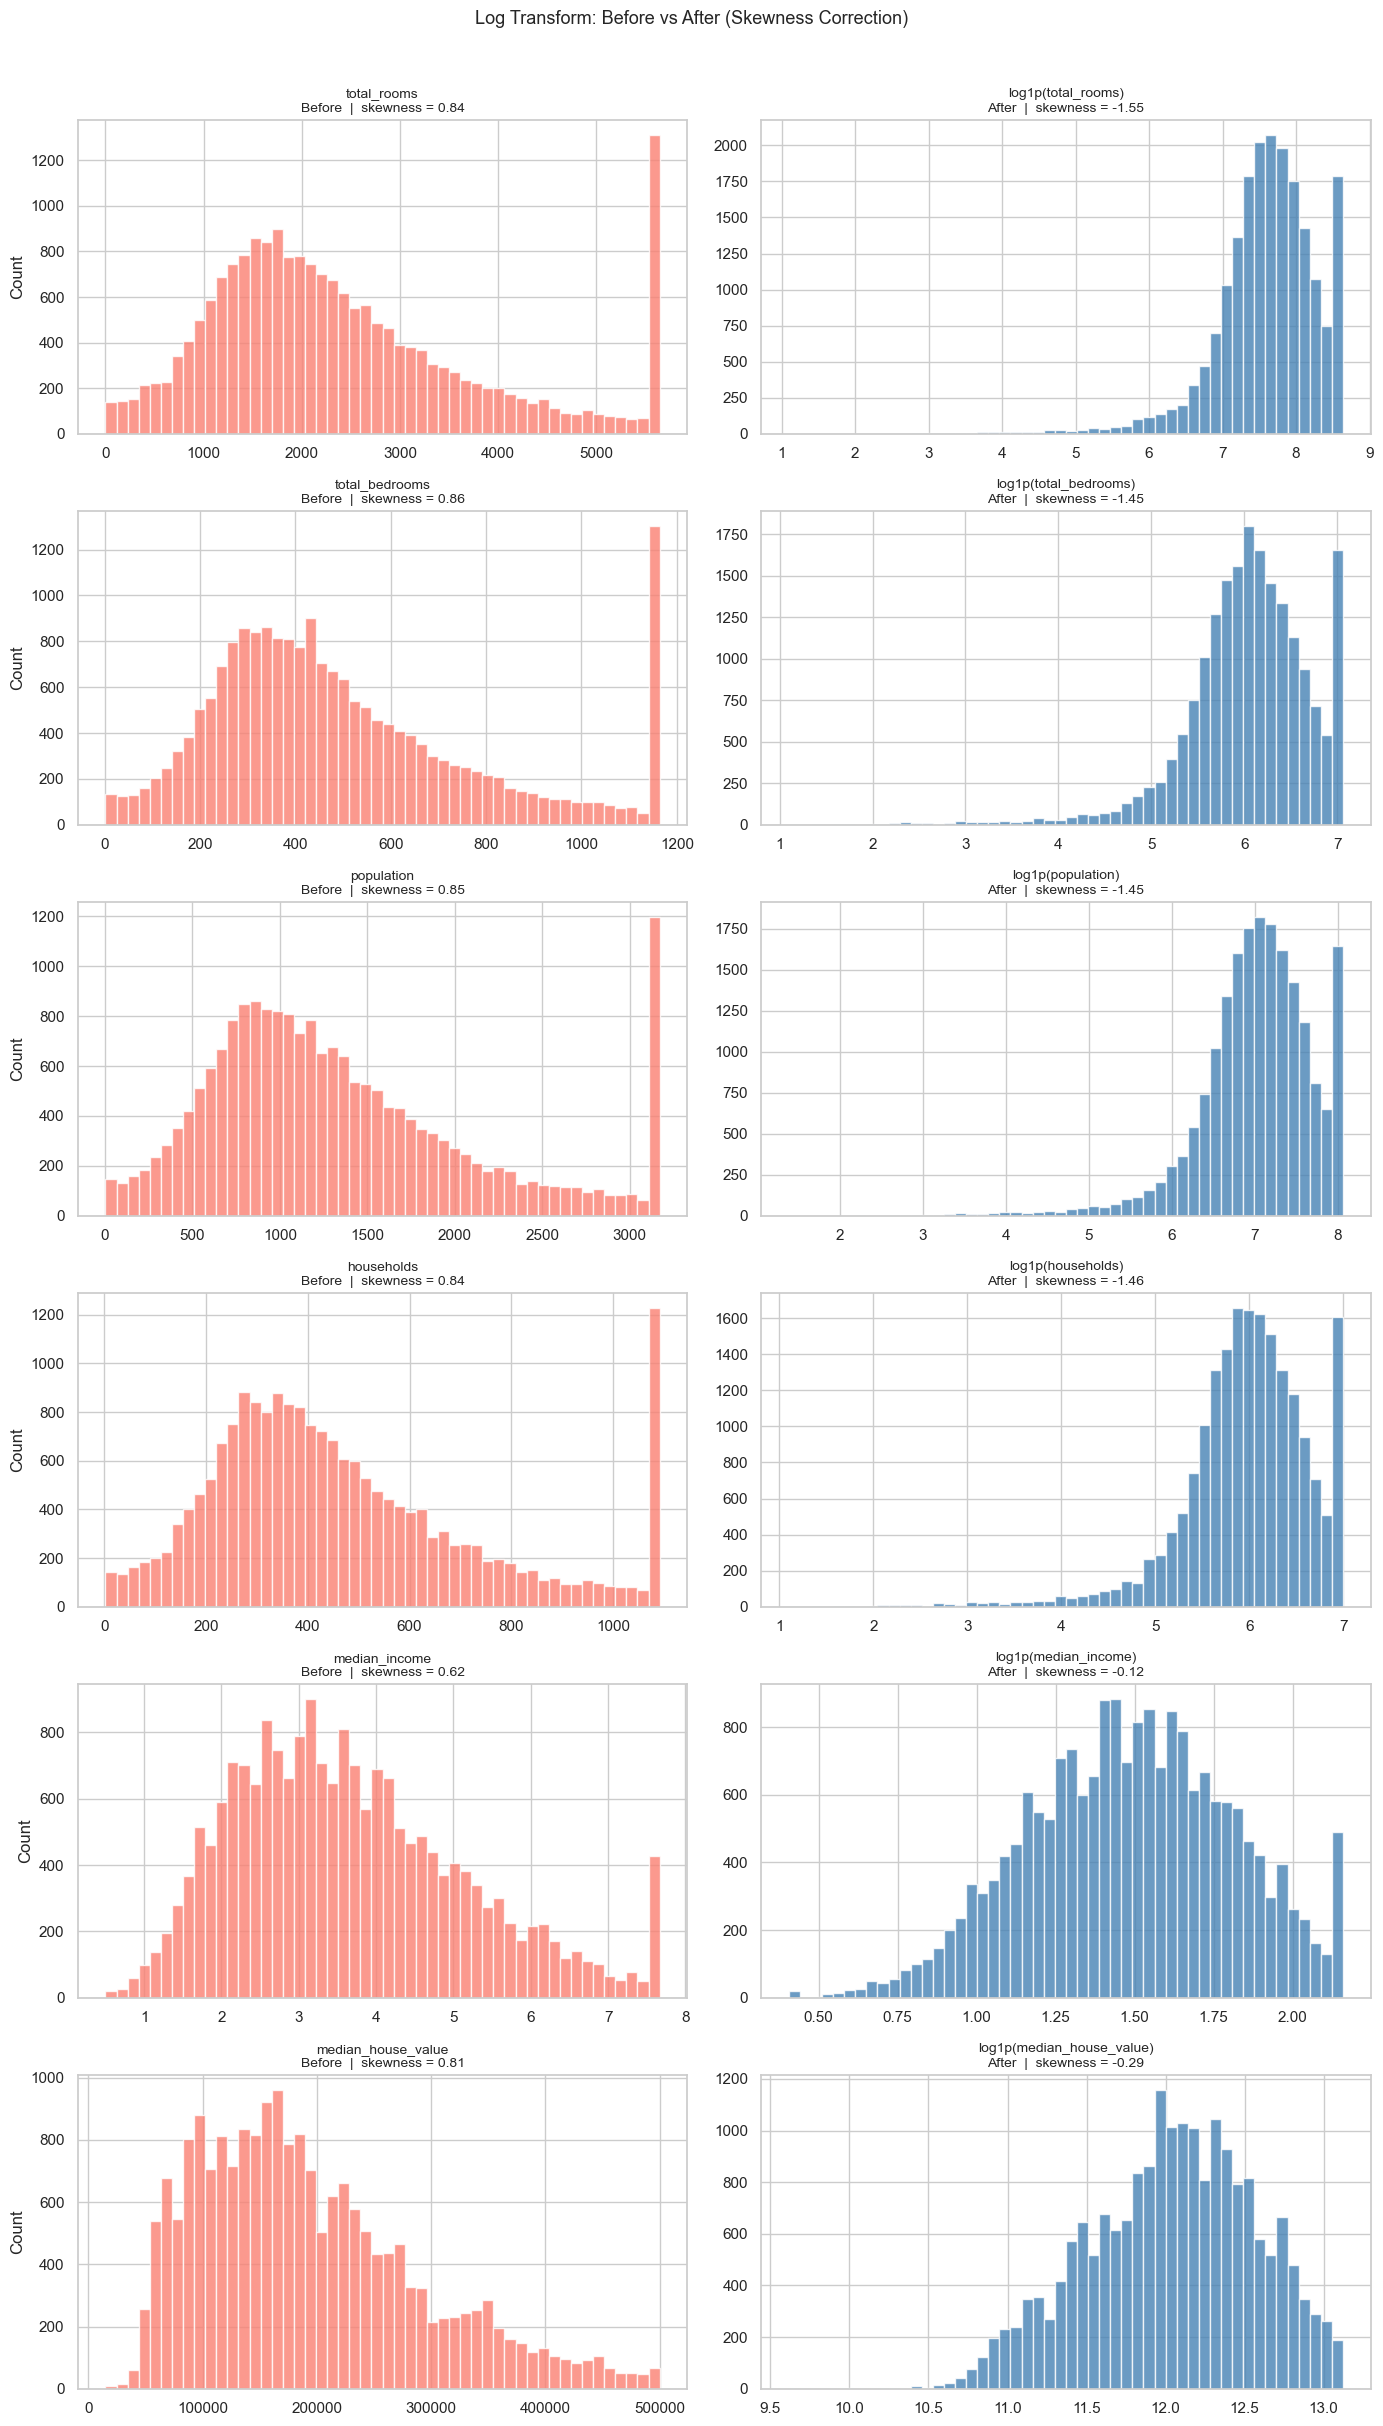

In [17]:
skew_cols = ["total_rooms", "total_bedrooms", "population", "households", "median_income", "median_house_value"]

# Plot before vs after for each column
fig, axes = plt.subplots(len(skew_cols), 2, figsize=(14, 4 * len(skew_cols)))

for i, col in enumerate(skew_cols):
    before_skew = df[col].skew()
    log_vals = np.log1p(df[col])
    after_skew = log_vals.skew()

    axes[i, 0].hist(df[col], bins=50, color="salmon", edgecolor="white", alpha=0.8)
    axes[i, 0].set_title(f"{col}\nBefore  |  skewness = {before_skew:.2f}", fontsize=10)
    axes[i, 0].set_ylabel("Count")

    axes[i, 1].hist(log_vals, bins=50, color="steelblue", edgecolor="white", alpha=0.8)
    axes[i, 1].set_title(f"log1p({col})\nAfter  |  skewness = {after_skew:.2f}", fontsize=10)

plt.suptitle("Log Transform: Before vs After (Skewness Correction)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [18]:
# Apply log1p transform and store original column names for reference
log_transformed_cols = skew_cols.copy()

for col in log_transformed_cols:
    df[col] = np.log1p(df[col])

print("Log1p transform applied to:")
for col in log_transformed_cols:
    print(f"  {col:25s} → new skewness: {df[col].skew():.3f}")

print(f"\n> NOTE: These columns are now in log scale.")
print(f"> When predicting, apply np.expm1() to reverse the transform on the target column.")

Log1p transform applied to:
  total_rooms               → new skewness: -1.550
  total_bedrooms            → new skewness: -1.446
  population                → new skewness: -1.454
  households                → new skewness: -1.462
  median_income             → new skewness: -0.121
  median_house_value        → new skewness: -0.295

> NOTE: These columns are now in log scale.
> When predicting, apply np.expm1() to reverse the transform on the target column.


### Step 10 — Final Cleaned Dataset

In [19]:
print("=" * 50)
print("CLEANED DATASET SUMMARY")
print("=" * 50)
print(f"Shape          : {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Missing values : {df.isnull().sum().sum()}")
print(f"Duplicates     : {df.duplicated().sum()}")
print(f"Dtypes         :\n{df.dtypes}")
print("\nSample:")
df.head()

# Save cleaned dataset
df.to_csv("housing_cleaned.csv", index=False)
print("\nCleaned dataset saved to housing_cleaned.csv")

CLEANED DATASET SUMMARY
Shape          : 19675 rows x 10 columns
Missing values : 0
Duplicates     : 0
Dtypes         :
longitude              float64
latitude               float64
housing_median_age     float64
total_rooms            float64
total_bedrooms         float64
population             float64
households             float64
median_income          float64
median_house_value     float64
ocean_proximity       category
dtype: object

Sample:

Cleaned dataset saved to housing_cleaned.csv


---
## Chunk 2: EDA + Statistical Analysis

**Goal:** Understand the data deeply before touching any model.
A model built without EDA is guesswork. EDA tells you which features matter, how they relate to the target, and whether any assumptions are violated.

**Steps:**
1. Target variable analysis (distribution + normality tests)
2. Feature distributions (histograms)
3. Correlation heatmap
4. Feature vs target scatter plots
5. Lat/Lon → combined distance feature + scatter plot
6. Geographical analysis (latitude/longitude map)
7. House value by ocean proximity (boxplot)
8. Statistical tests — ANOVA + effect size, Spearman correlation
9. VIF — Variance Inflation Factor (multicollinearity check)

### Step 1 — Target Variable Analysis

Before analyzing features, always study the target first.
If the target is highly skewed or non-normal, it affects which metrics and models you should use.

**Three normality checks explained:**

**1. Shapiro-Wilk Test**
- Measures how well the data's quantiles match a perfect normal distribution's quantiles
- Gives a W statistic (0 to 1) and a p-value
- p-value < 0.05 → reject the hypothesis that data is normal
- **Critical limitation:** On large datasets (n > 5,000), it becomes hypersensitive. Even a distribution that is 99% normal will give p < 0.05 because the test detects microscopic deviations. For 19,675 rows it will almost always reject normality — so we use it as a weak signal only.

**2. D'Agostino K² Test**
- More balanced for large samples than Shapiro-Wilk
- Combines two things into one test:
  - **Skewness** → is the distribution asymmetric (tail heavier on one side)?
  - **Kurtosis** → are the tails too heavy or too light vs a normal distribution?
- Same interpretation: p < 0.05 → non-normal. But still has large-sample sensitivity.
- **Rule of thumb:** On large data, trust the visual (QQ plot) more than the p-value.

**3. QQ Plot (Quantile-Quantile Plot)**
- Most honest normality check, especially for large data
- X-axis: what the values *should be* if the data were perfectly normal
- Y-axis: what the values *actually are*
- **If perfectly normal** → all points lie exactly on the diagonal line
- **Deviations tell you the problem:**
  - S-shaped curve → distribution is skewed
  - Points curl up at top-right → heavy right tail (large outliers)
  - Points curl down at bottom-left → heavy left tail
  - Points hug the line → near-normal ✓

**Why do we check normality of the target at all?**
Linear regression doesn't require the *target* to be normal — it requires the *residuals* (errors after fitting) to be normal. But in practice, a severely skewed target produces skewed residuals too. Log-transforming the target (which we already did in Step 9 of Chunk 1) makes residuals more normal and improves linear model performance. The QQ plot here confirms that log transform was the right call.

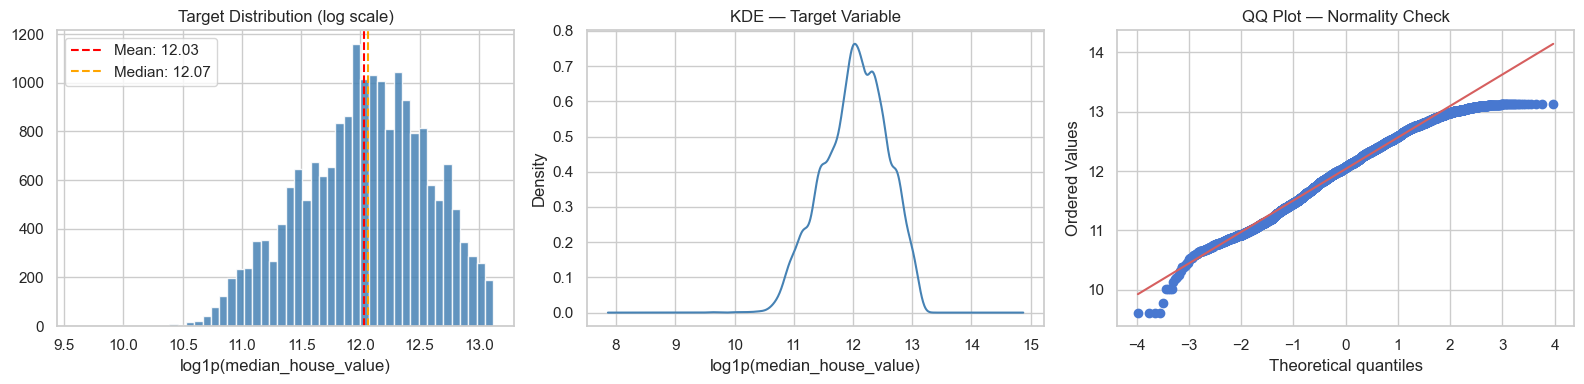


D'Agostino K² Normality Test:
  Statistic : 442.4740
  p-value   : 0.000000
  Verdict   : Non-normal (p < 0.05)

Skewness : -0.2948
Kurtosis : -0.3678


In [20]:
target = df["median_house_value"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Distribution
axes[0].hist(target, bins=50, color="steelblue", edgecolor="white", alpha=0.85)
axes[0].axvline(target.mean(), color="red", linestyle="--", label=f"Mean: {target.mean():.2f}")
axes[0].axvline(target.median(), color="orange", linestyle="--", label=f"Median: {target.median():.2f}")
axes[0].set_title("Target Distribution (log scale)")
axes[0].set_xlabel("log1p(median_house_value)")
axes[0].legend()

# KDE
target.plot(kind="kde", ax=axes[1], color="steelblue")
axes[1].set_title("KDE — Target Variable")
axes[1].set_xlabel("log1p(median_house_value)")

# QQ Plot
stats.probplot(target, dist="norm", plot=axes[2])
axes[2].set_title("QQ Plot — Normality Check")

plt.tight_layout()
plt.show()

# Statistical normality test
stat, p = stats.normaltest(target)
print(f"\nD'Agostino K² Normality Test:")
print(f"  Statistic : {stat:.4f}")
print(f"  p-value   : {p:.6f}")
print(f"  Verdict   : {'Non-normal (p < 0.05)' if p < 0.05 else 'Normal (p >= 0.05)'}")
print(f"\nSkewness : {target.skew():.4f}")
print(f"Kurtosis : {target.kurt():.4f}")

### Step 2 — Feature Distributions

Visualize all features to understand their shape, spread, and any remaining issues post-cleaning.

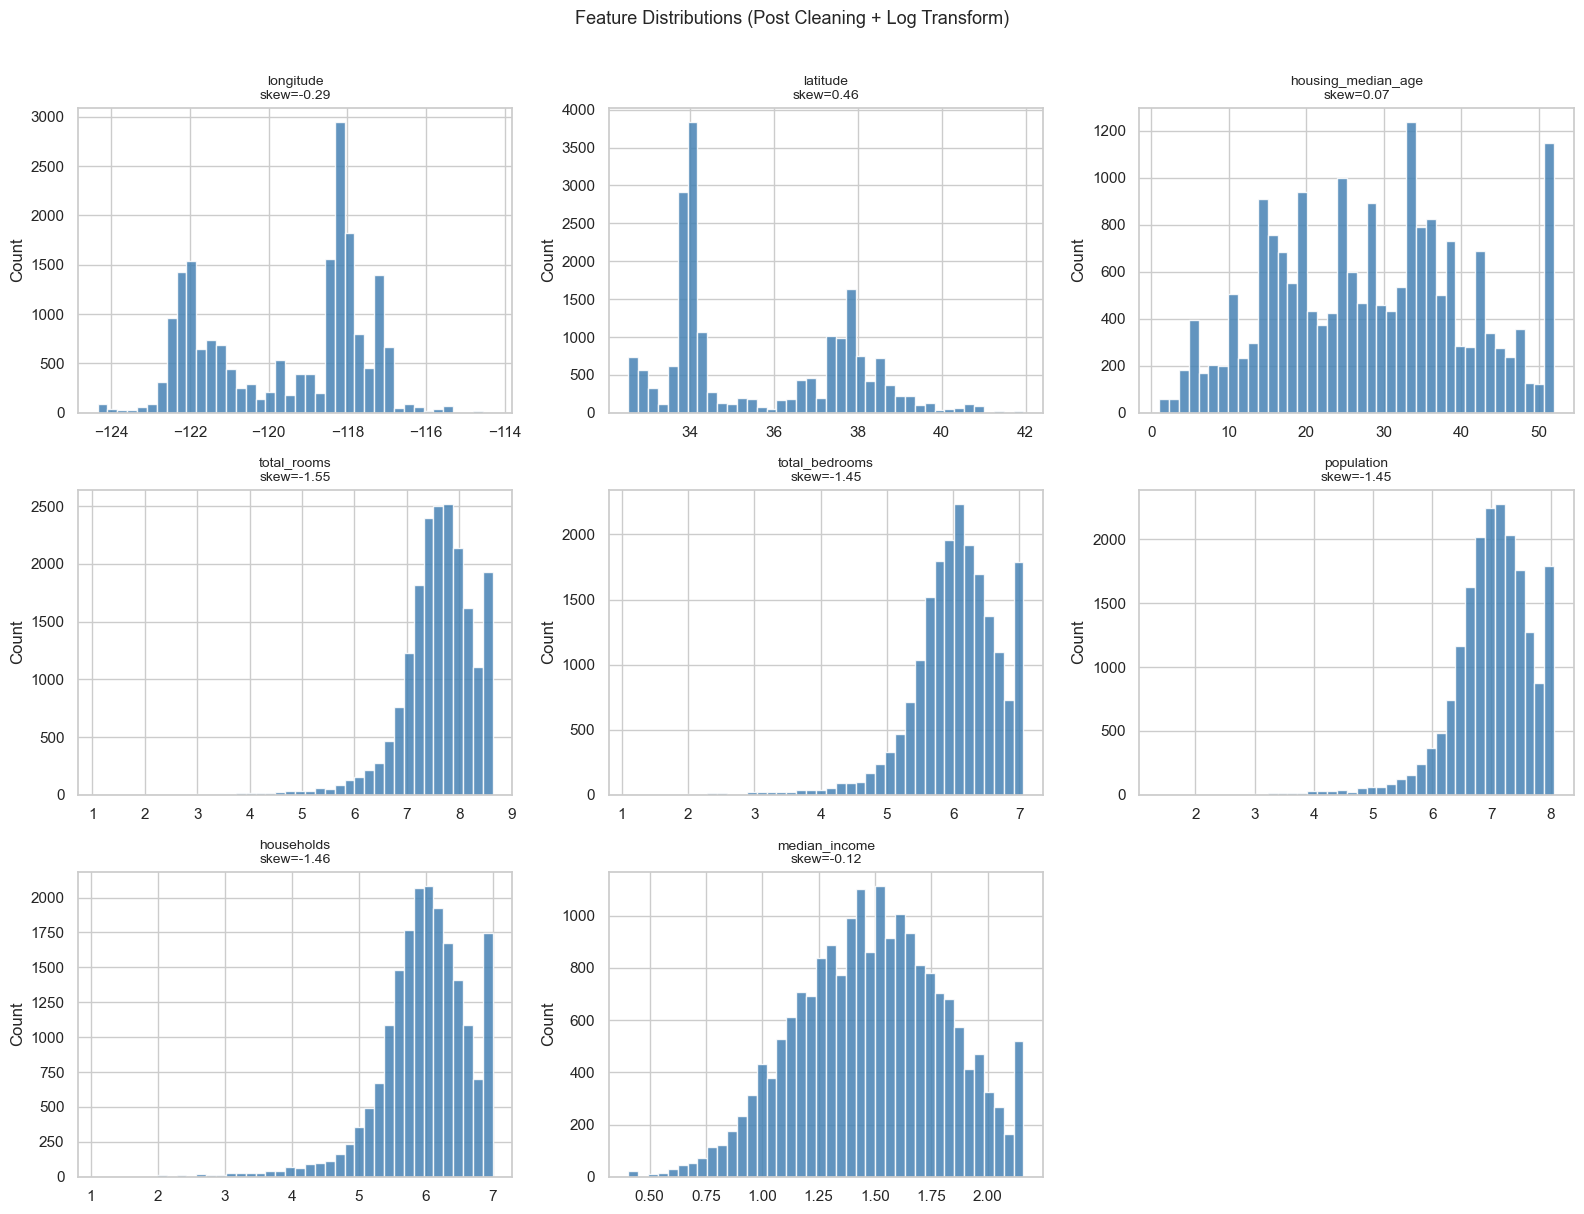

In [21]:
feature_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c != "median_house_value"]

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    axes[i].hist(df[col], bins=40, color="steelblue", edgecolor="white", alpha=0.85)
    axes[i].set_title(f"{col}\nskew={df[col].skew():.2f}", fontsize=10)
    axes[i].set_ylabel("Count")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Feature Distributions (Post Cleaning + Log Transform)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### Step 3 — Correlation Heatmap

**Pearson correlation** measures the linear relationship between two variables.
- Values close to **+1** → strong positive linear relationship
- Values close to **-1** → strong negative linear relationship
- Values close to **0** → no linear relationship

> **Important:** Correlation tells you strength of linear relationship only. Two variables can have a strong non-linear relationship but show low Pearson correlation. We address this with scatter plots in Step 4.

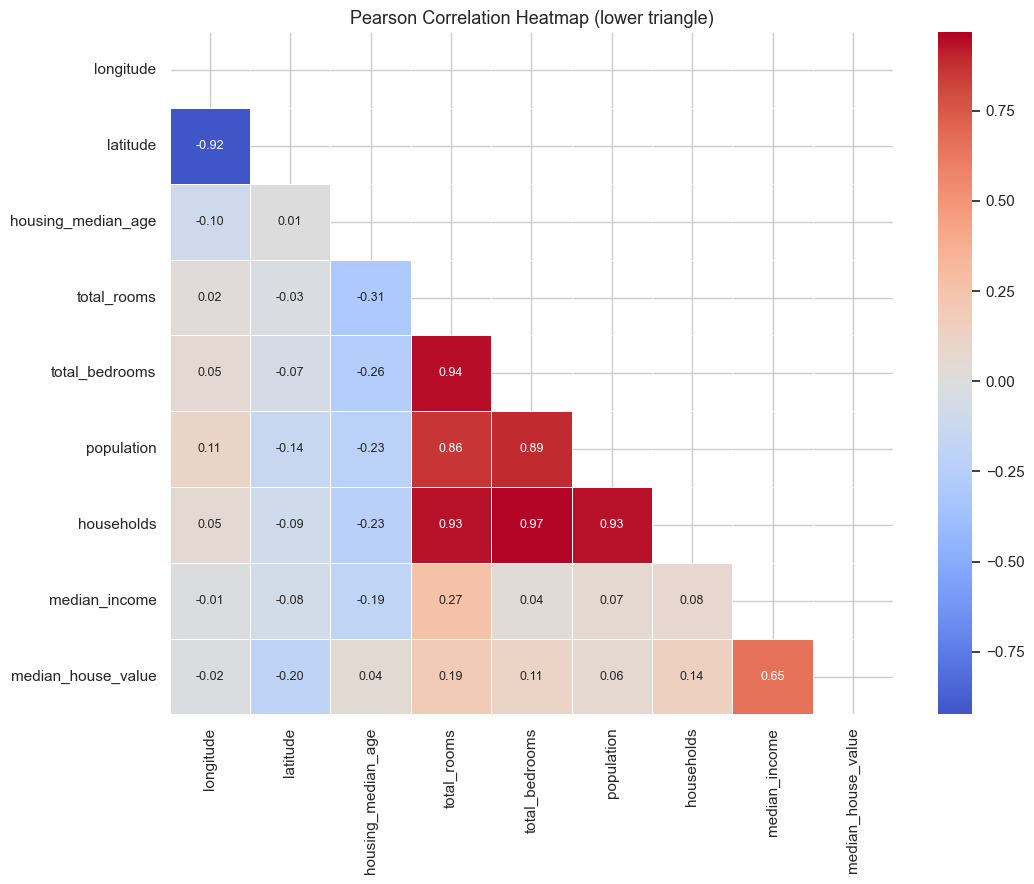


Correlation with target (median_house_value) — sorted:
median_income         0.65
total_rooms           0.19
households            0.14
total_bedrooms        0.11
population            0.06
housing_median_age    0.04
longitude            -0.02
latitude             -0.20
Name: median_house_value, dtype: float64


In [22]:
num_df = df.select_dtypes(include=[np.number])
corr_matrix = num_df.corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, ax=ax, annot_kws={"size": 9})
ax.set_title("Pearson Correlation Heatmap (lower triangle)", fontsize=13)
plt.tight_layout()
plt.show()

# Print correlations with target specifically
print("\nCorrelation with target (median_house_value) — sorted:")
print(corr_matrix["median_house_value"].drop("median_house_value").sort_values(ascending=False).round(3))

### Step 4 — Feature vs Target Scatter Plots

**What are we trying to see?**
The scatter plot puts each feature on the X-axis and the target (`median_house_value`) on the Y-axis. Every dot is one district. The pattern of dots tells us the *nature* of the relationship.

**Four patterns and what they mean:**

| Pattern | What it looks like | What it means |
|---|---|---|
| **Diagonal band** | Points form a clear line going up or down | Strong linear relationship — linear models will work well |
| **Curve** | Points follow a curve (not a straight line) | Non-linear relationship — need polynomial feature or tree model |
| **Random cloud** | Points scattered with no direction | Feature carries no signal for the target — candidate for removal |
| **Funnel shape** | Spread of points grows wider as X increases | Heteroscedasticity — variance of errors is not constant, violates linear regression assumptions |

**What is the ideal scatter plot for a regression feature?**
A tight diagonal band (positive or negative slope) where points cluster close to an imaginary straight line. The tighter the band, the stronger and cleaner the relationship.

**Why longitude and latitude individually look weak:**
`longitude` and `latitude` alone show scattered, non-linear patterns — not a clean diagonal. That's because location value is not driven by being "east or west" or "north or south" in isolation. What matters is the *combination* — being close to San Francisco or Los Angeles. A single coordinate is meaningless; the pair together encodes location. We fix this in Step 5 by engineering a new distance feature from both columns.

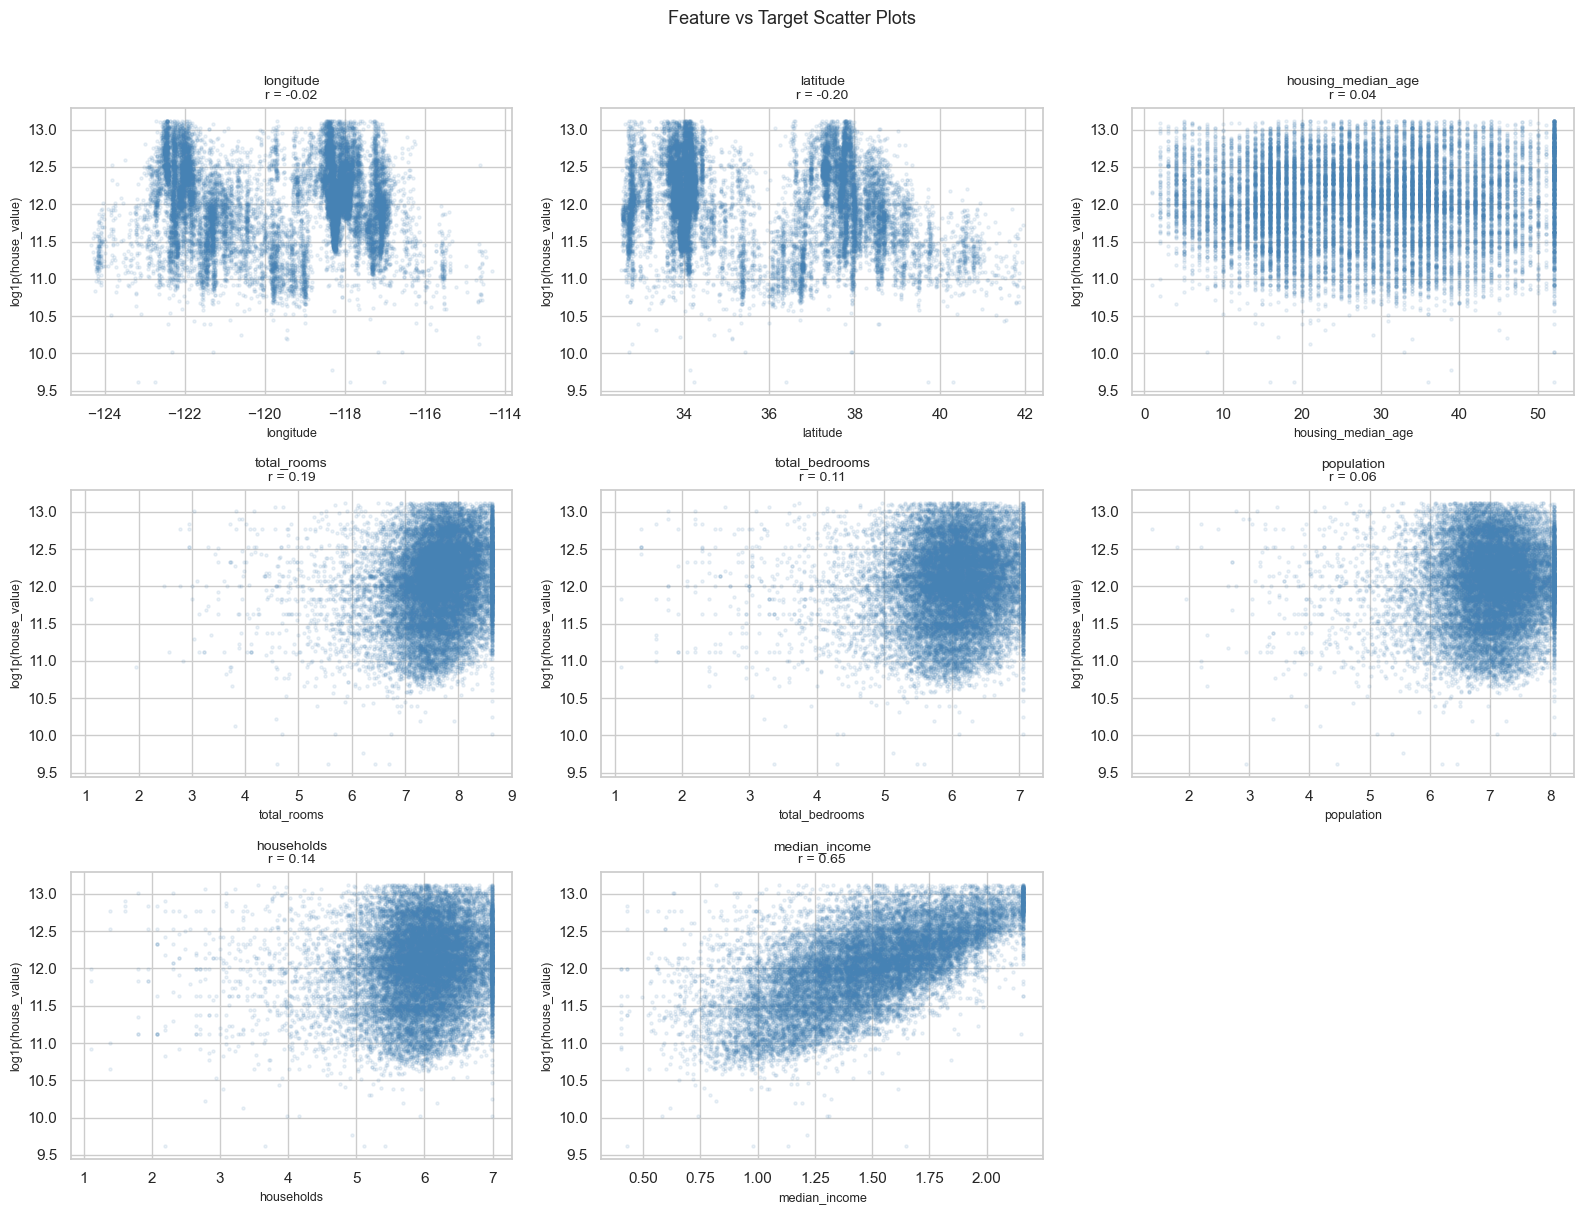

In [23]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    axes[i].scatter(df[col], df["median_house_value"], alpha=0.1, s=5, color="steelblue")
    axes[i].set_xlabel(col, fontsize=9)
    axes[i].set_ylabel("log1p(house_value)", fontsize=9)
    corr_val = df[col].corr(df["median_house_value"])
    axes[i].set_title(f"{col}\nr = {corr_val:.2f}", fontsize=10)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Feature vs Target Scatter Plots", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### Step 5 — Lat/Lon → Combined Distance Feature

**The problem with raw lat/lon:**
`latitude = 37.8` means nothing on its own. `longitude = -122.4` means nothing on its own.
But together they describe San Francisco — the most expensive real estate cluster in the dataset.
Individual scatter plots can't capture this — the relationship is 2D, not 1D.

**Solution — engineer a single meaningful feature: distance to nearest major city hub**

California's two dominant housing price centers are:
- **San Francisco** (37.77°N, 122.42°W) — Bay Area premium
- **Los Angeles** (34.05°N, 118.24°W) — LA metro premium

We calculate Euclidean distance from each district to both cities, then take the minimum.
This collapses two weak individual features into one strong combined feature.

**Why Euclidean (not Haversine)?**
California spans only ~10° latitude and ~10° longitude — at this scale, Euclidean distance introduces less than 0.5% error vs the more accurate Haversine formula. Haversine is necessary for continental or global distances. Here it adds complexity without meaningful gain.

**Expected result:** Districts closer to SF or LA → higher house value → negative correlation with distance → scatter plot should show a clear downward diagonal band.

In [24]:
# Major California city coordinates
SF  = (37.7749, -122.4194)
LA  = (34.0522, -118.2437)
SD  = (32.7157, -117.1611)  # San Diego — third major hub

def euclidean_dist(lat, lon, ref_lat, ref_lon):
    return np.sqrt((lat - ref_lat)**2 + (lon - ref_lon)**2)

df["dist_to_sf"] = euclidean_dist(df["latitude"], df["longitude"], SF[0], SF[1])
df["dist_to_la"] = euclidean_dist(df["latitude"], df["longitude"], LA[0], LA[1])
df["dist_to_sd"] = euclidean_dist(df["latitude"], df["longitude"], SD[0], SD[1])

# Combined: distance to nearest major hub
df["dist_to_nearest_hub"] = df[["dist_to_sf", "dist_to_la", "dist_to_sd"]].min(axis=1)

print("New features created:")
print(df[["latitude", "longitude", "dist_to_sf", "dist_to_la", "dist_to_sd", "dist_to_nearest_hub"]].head(8))

corr_dist = df["dist_to_nearest_hub"].corr(df["median_house_value"])
print(f"\nCorrelation of dist_to_nearest_hub with median_house_value: {corr_dist:.3f}")

New features created:
   latitude  longitude  dist_to_sf  dist_to_la  dist_to_sd  \
0     37.88    -122.23        0.22        5.53        7.24   
1     37.86    -122.22        0.22        5.51        7.22   
2     37.85    -122.24        0.19        5.51        7.22   
3     37.85    -122.25        0.19        5.52        7.23   
4     37.85    -122.25        0.19        5.52        7.23   
5     37.85    -122.25        0.19        5.52        7.23   
6     37.84    -122.25        0.18        5.51        7.22   
7     37.84    -122.25        0.18        5.51        7.22   

   dist_to_nearest_hub  
0                 0.22  
1                 0.22  
2                 0.19  
3                 0.19  
4                 0.19  
5                 0.19  
6                 0.18  
7                 0.18  

Correlation of dist_to_nearest_hub with median_house_value: -0.523


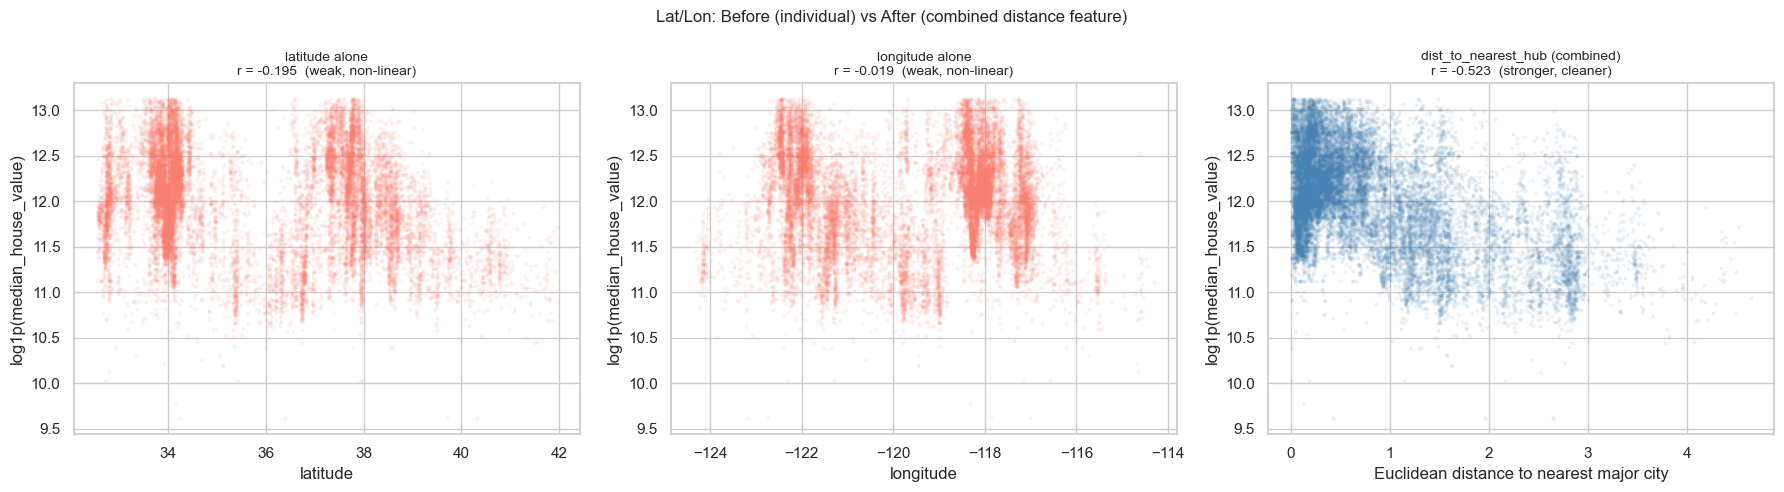

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Before: latitude alone
r_lat = df["latitude"].corr(df["median_house_value"])
axes[0].scatter(df["latitude"], df["median_house_value"], alpha=0.07, s=4, color="salmon")
axes[0].set_title(f"latitude alone\nr = {r_lat:.3f}  (weak, non-linear)", fontsize=10)
axes[0].set_xlabel("latitude")
axes[0].set_ylabel("log1p(median_house_value)")

# Before: longitude alone
r_lon = df["longitude"].corr(df["median_house_value"])
axes[1].scatter(df["longitude"], df["median_house_value"], alpha=0.07, s=4, color="salmon")
axes[1].set_title(f"longitude alone\nr = {r_lon:.3f}  (weak, non-linear)", fontsize=10)
axes[1].set_xlabel("longitude")
axes[1].set_ylabel("log1p(median_house_value)")

# After: combined distance feature
r_dist = df["dist_to_nearest_hub"].corr(df["median_house_value"])
axes[2].scatter(df["dist_to_nearest_hub"], df["median_house_value"], alpha=0.07, s=4, color="steelblue")
axes[2].set_title(f"dist_to_nearest_hub (combined)\nr = {r_dist:.3f}  (stronger, cleaner)", fontsize=10)
axes[2].set_xlabel("Euclidean distance to nearest major city")
axes[2].set_ylabel("log1p(median_house_value)")

plt.suptitle("Lat/Lon: Before (individual) vs After (combined distance feature)", fontsize=12)
plt.tight_layout()
plt.show()

### Step 5 — Geographical Analysis

This dataset has `latitude` and `longitude` for every district.
Plotting them reveals the map of California — and coloring by house value shows which regions are expensive.

> This is a powerful EDA step unique to spatial data. It can reveal location-driven price clusters that no correlation number would show you.

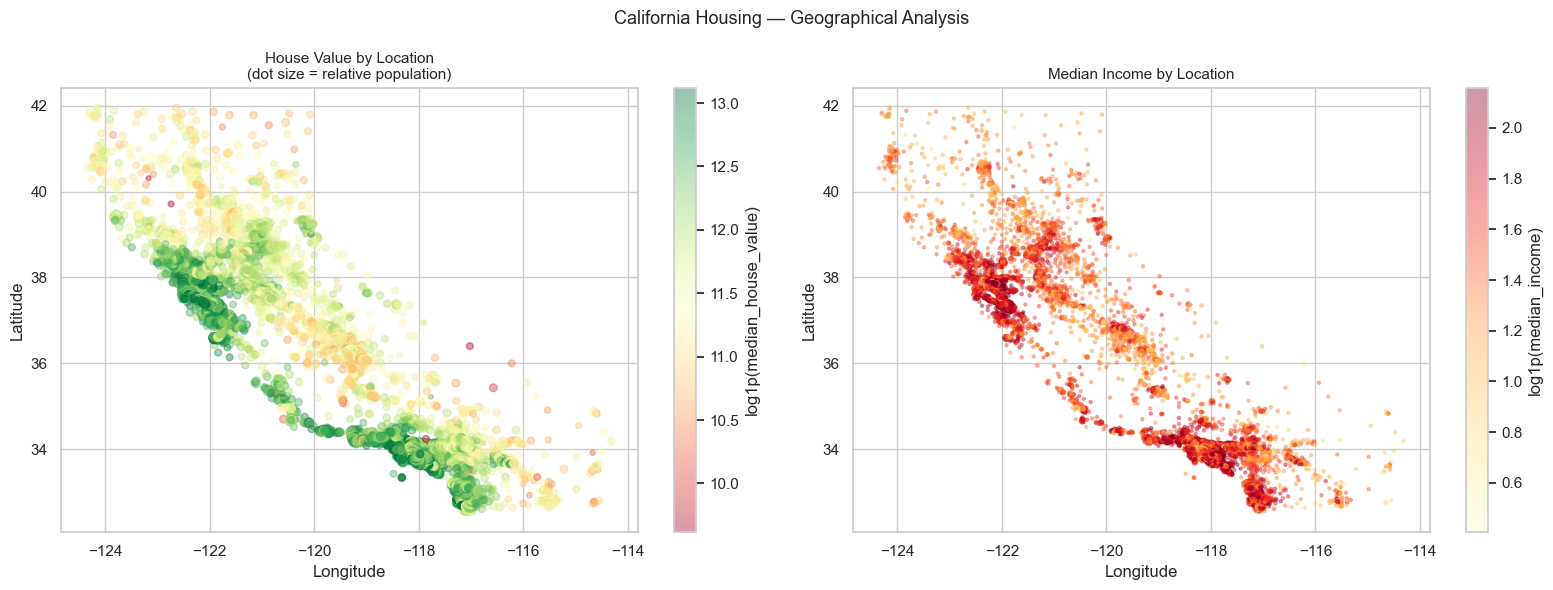

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# House value map
sc = axes[0].scatter(df["longitude"], df["latitude"],
                     c=df["median_house_value"], cmap="RdYlGn",
                     alpha=0.4, s=df["population"] / df["population"].max() * 30 + 1)
plt.colorbar(sc, ax=axes[0], label="log1p(median_house_value)")
axes[0].set_title("House Value by Location\n(dot size = relative population)", fontsize=11)
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")

# Median income map
sc2 = axes[1].scatter(df["longitude"], df["latitude"],
                      c=df["median_income"], cmap="YlOrRd",
                      alpha=0.4, s=5)
plt.colorbar(sc2, ax=axes[1], label="log1p(median_income)")
axes[1].set_title("Median Income by Location", fontsize=11)
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")

plt.suptitle("California Housing — Geographical Analysis", fontsize=13)
plt.tight_layout()
plt.show()

### Step 6 — House Value by Ocean Proximity (Boxplot)

Does proximity to the ocean meaningfully affect house price? Boxplots let us compare the distribution of the target across each category.

/var/folders/mw/jbc41xx11gq3v2wqc8yz62400000gn/T/ipykernel_23285/3326874403.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  order = df.groupby("ocean_proximity")["median_house_value"].median().sort_values(ascending=False).index
/var/folders/mw/jbc41xx11gq3v2wqc8yz62400000gn/T/ipykernel_23285/3326874403.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="ocean_proximity", y="median_house_value",
/var/folders/mw/jbc41xx11gq3v2wqc8yz62400000gn/T/ipykernel_23285/3326874403.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False`

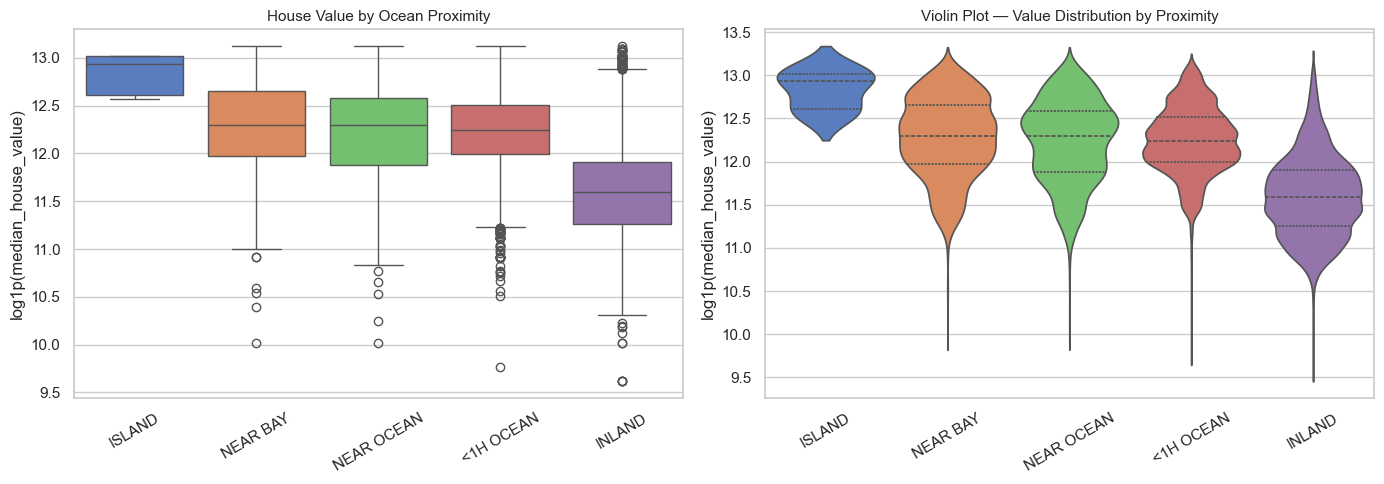

Median house value per ocean_proximity group:
ocean_proximity
ISLAND       12.94
NEAR BAY     12.30
NEAR OCEAN   12.29
<1H OCEAN    12.24
INLAND       11.59
Name: median_house_value, dtype: float64


/var/folders/mw/jbc41xx11gq3v2wqc8yz62400000gn/T/ipykernel_23285/3326874403.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby("ocean_proximity")["median_house_value"].median().sort_values(ascending=False).round(3))


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order = df.groupby("ocean_proximity")["median_house_value"].median().sort_values(ascending=False).index

sns.boxplot(data=df, x="ocean_proximity", y="median_house_value",
            order=order, palette="muted", ax=axes[0])
axes[0].set_title("House Value by Ocean Proximity", fontsize=11)
axes[0].set_xlabel("")
axes[0].set_ylabel("log1p(median_house_value)")
axes[0].tick_params(axis="x", rotation=30)

sns.violinplot(data=df, x="ocean_proximity", y="median_house_value",
               order=order, palette="muted", ax=axes[1], inner="quartile")
axes[1].set_title("Violin Plot — Value Distribution by Proximity", fontsize=11)
axes[1].set_xlabel("")
axes[1].set_ylabel("log1p(median_house_value)")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

print("Median house value per ocean_proximity group:")
print(df.groupby("ocean_proximity")["median_house_value"].median().sort_values(ascending=False).round(3))

### Step 8 — Statistical Tests (with Effect Size)

**Why p-value alone is not enough:**
P-value only answers: *"Is there a statistically significant difference?"*
With 19,675 rows, almost everything will be significant (p < 0.05) — even a difference so tiny it means nothing in practice.

**Effect size answers the real question: "How large is the difference?"**
Always report both together. A finding with p < 0.001 but tiny effect size is statistically real but practically useless.

---

**A) ANOVA + Effect Size (Eta Squared η²) — `ocean_proximity` vs `median_house_value`**

ANOVA tests whether group means differ. Eta squared measures *how much* of the total variance is explained by the grouping.

```
η² = SS_between_groups / SS_total
```

| η² value | Interpretation |
|---|---|
| < 0.01 | Trivial effect |
| 0.01 – 0.06 | Small effect |
| 0.06 – 0.14 | Medium effect |
| > 0.14 | Large effect |

---

**B) Spearman Correlation — numerical features vs `median_house_value`**

Unlike Pearson, Spearman captures **monotonic** relationships (not just linear). Better here because our log-transformed features may still have non-linear patterns.

The **Spearman ρ (rho) value IS the effect size** — no separate calculation needed:

| |ρ| value | Interpretation |
|---|---|
| < 0.10 | Trivial |
| 0.10 – 0.30 | Small |
| 0.30 – 0.50 | Medium |
| > 0.50 | Large |

In [28]:
# A) One-Way ANOVA + Eta Squared effect size
groups = [group["median_house_value"].values for _, group in df.groupby("ocean_proximity", observed=False)]
f_stat, p_val = stats.f_oneway(*groups)

# Eta squared = SS_between / SS_total
grand_mean = df["median_house_value"].mean()
ss_total = ((df["median_house_value"] - grand_mean) ** 2).sum()
ss_between = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in groups)
eta_sq = ss_between / ss_total

eta_label = ("Trivial" if eta_sq < 0.01 else
             "Small"   if eta_sq < 0.06 else
             "Medium"  if eta_sq < 0.14 else "Large")

print("=" * 60)
print("ANOVA — ocean_proximity vs median_house_value")
print("=" * 60)
print(f"  F-statistic  : {f_stat:.4f}")
print(f"  p-value      : {p_val:.2e}")
print(f"  Eta squared  : {eta_sq:.4f}  → {eta_label} effect")
print(f"  Meaning      : ocean_proximity explains {eta_sq*100:.1f}% of variance in house value")

# B) Spearman Correlation + effect size label
all_feat_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c != "median_house_value"]

print("\n" + "=" * 60)
print("Spearman Correlation — Features vs Target (with Effect Size)")
print("=" * 60)
spearman_results = []
for col in all_feat_cols:
    rho, p = stats.spearmanr(df[col], df["median_house_value"])
    abs_rho = abs(rho)
    effect = ("Trivial" if abs_rho < 0.10 else
              "Small"   if abs_rho < 0.30 else
              "Medium"  if abs_rho < 0.50 else "Large")
    spearman_results.append({
        "Feature": col, "Spearman ρ": round(rho, 3),
        "p-value": f"{p:.2e}", "Effect Size": effect,
        "Sig": "✓" if p < 0.05 else "✗"
    })

spearman_df = (pd.DataFrame(spearman_results)
               .set_index("Feature")
               .sort_values("Spearman ρ", ascending=False, key=abs))
print(spearman_df)

ANOVA — ocean_proximity vs median_house_value
  F-statistic  : 2337.1600
  p-value      : 0.00e+00
  Eta squared  : 0.3222  → Large effect
  Meaning      : ocean_proximity explains 32.2% of variance in house value

Spearman Correlation — Features vs Target (with Effect Size)
                     Spearman ρ    p-value Effect Size Sig
Feature                                                   
median_income              0.65   0.00e+00       Large   ✓
dist_to_nearest_hub       -0.41   0.00e+00      Medium   ✓
total_rooms                0.21  3.74e-187       Small   ✓
dist_to_la                -0.17  1.30e-126       Small   ✓
latitude                  -0.17  1.18e-124       Small   ✓
households                 0.14   1.87e-81       Small   ✓
total_bedrooms             0.11   2.36e-50       Small   ✓
dist_to_sd                -0.09   1.29e-34     Trivial   ✓
dist_to_sf                -0.07   1.16e-25     Trivial   ✓
longitude                 -0.06   3.95e-17     Trivial   ✓
housing_median_a

### Step 9 — VIF (Variance Inflation Factor) — Multicollinearity Check

**What is multicollinearity?**
When two or more features are highly correlated with each other (not with the target — with *each other*). You already spotted this in the heatmap: `total_rooms`, `total_bedrooms`, `households`, `population` are all strongly correlated.

**Why is this a problem?**
For **linear models**: If Feature A can be predicted from Feature B, the model cannot separate their individual effects. It assigns unstable, unreliable coefficients — small changes in data lead to wildly different coefficients. The model still predicts reasonably but you cannot trust the feature importance.

For **tree models**: Much less of a problem. Trees pick one feature per split regardless.

**What is VIF?**
VIF measures how much the variance of a feature's coefficient is inflated because of its correlation with other features.

```
VIF for Feature X = 1 / (1 - R²)
where R² = how well Feature X can be predicted by ALL other features combined
```

| VIF | Interpretation | Action |
|---|---|---|
| 1 | No correlation with other features | ✓ Clean |
| 1 – 5 | Moderate — acceptable | ✓ Keep |
| 5 – 10 | High — concerning | ⚠ Investigate |
| > 10 | Severe multicollinearity | ✗ Drop, combine, or use Ridge/Lasso |

**What to do when VIF is high — three options:**
1. **Drop** one of the correlated features (the weaker one by Spearman ρ)
2. **Combine** them into a ratio (e.g., `rooms_per_household = total_rooms / households`) — extracts the unique information
3. **Use Ridge or Lasso** — these models penalize large coefficients and handle multicollinearity naturally

We will calculate VIF here and decide in Chunk 3 (Feature Engineering).

Variance Inflation Factor (VIF) — Multicollinearity Check:
                         VIF    Status
Feature                               
latitude            11198.77  ✗ Severe
longitude            9250.92  ✗ Severe
total_rooms          2584.92  ✗ Severe
total_bedrooms       2186.28  ✗ Severe
households           2160.01  ✗ Severe
population            837.44  ✗ Severe
dist_to_sd            224.03  ✗ Severe
median_income          55.35  ✗ Severe
dist_to_sf             49.28  ✗ Severe
dist_to_la             29.93  ✗ Severe
housing_median_age      8.76    ⚠ High
dist_to_nearest_hub     4.72   ✓ Clean


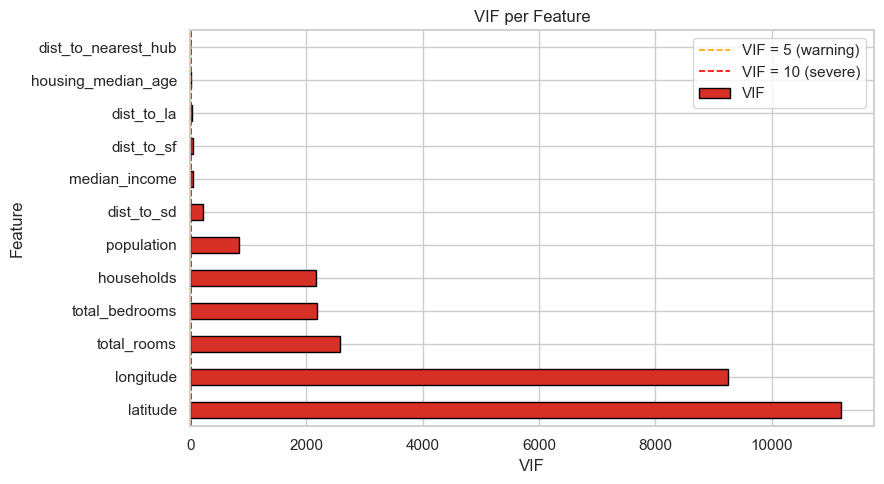

In [29]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# VIF only works on numerical features — exclude target and add constant
vif_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c != "median_house_value"]
vif_df_input = df[vif_cols].dropna()

vif_results = []
for i, col in enumerate(vif_cols):
    vif_val = variance_inflation_factor(vif_df_input.values, i)
    flag = ("✓ Clean"    if vif_val < 5  else
            "⚠ High"     if vif_val < 10 else
            "✗ Severe")
    vif_results.append({"Feature": col, "VIF": round(vif_val, 2), "Status": flag})

vif_table = pd.DataFrame(vif_results).set_index("Feature").sort_values("VIF", ascending=False)
print("Variance Inflation Factor (VIF) — Multicollinearity Check:")
print(vif_table)

# Visual
fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#d73027" if v > 10 else "#fc8d59" if v > 5 else "#91bfdb"
          for v in vif_table["VIF"]]
vif_table["VIF"].plot(kind="barh", ax=ax, color=colors, edgecolor="black")
ax.axvline(5,  color="orange", linestyle="--", linewidth=1.2, label="VIF = 5 (warning)")
ax.axvline(10, color="red",    linestyle="--", linewidth=1.2, label="VIF = 10 (severe)")
ax.set_title("VIF per Feature")
ax.set_xlabel("VIF")
ax.legend()
plt.tight_layout()
plt.show()

In [30]:
df[vif_cols]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,dist_to_sf,dist_to_la,dist_to_sd,dist_to_nearest_hub
0,-122.23,37.88,41.00,6.78,4.87,5.78,4.84,2.16,0.22,5.53,7.24,0.22
1,-122.22,37.86,21.00,8.64,7.01,7.78,7.00,2.16,0.22,5.51,7.22,0.22
2,-122.24,37.85,52.00,7.29,5.25,6.21,5.18,2.11,0.19,5.51,7.22,0.19
3,-122.25,37.85,52.00,7.15,5.46,6.33,5.39,1.89,0.19,5.52,7.23,0.19
4,-122.25,37.85,52.00,7.40,5.64,6.34,5.56,1.58,0.19,5.52,7.23,0.19
...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.00,7.42,5.93,6.74,5.80,0.94,2.16,6.13,7.82,2.16
20636,-121.21,39.49,18.00,6.55,5.02,5.88,4.74,1.27,2.10,6.19,7.89,2.10
20637,-121.22,39.43,17.00,7.72,6.19,6.92,6.07,0.99,2.04,6.15,7.85,2.04
20638,-121.32,39.43,18.00,7.53,6.02,6.61,5.86,1.05,1.99,6.20,7.90,1.99


VIF (correct method — with intercept):
                     VIF (with intercept)    Status
Feature                                            
dist_to_sd                         223.15  ✗ Severe
latitude                            75.59  ✗ Severe
longitude                           41.41  ✗ Severe
households                          28.71  ✗ Severe
total_bedrooms                      27.37  ✗ Severe
total_rooms                         22.07  ✗ Severe
dist_to_sf                          15.47  ✗ Severe
dist_to_la                          14.68  ✗ Severe
population                           8.22    ⚠ High
median_income                        2.55   ✓ Clean
dist_to_nearest_hub                  2.49   ✓ Clean
housing_median_age                   1.42   ✓ Clean


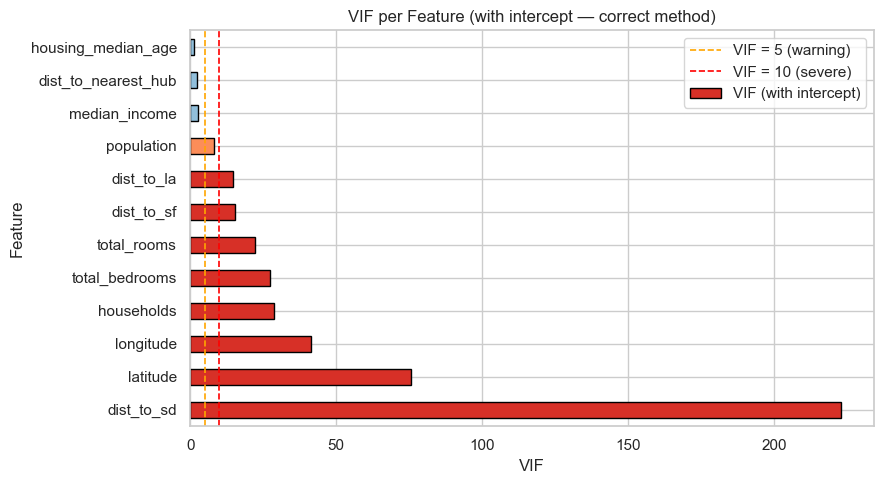

In [31]:
from statsmodels.tools.tools import add_constant

# Proper VIF calculation WITH intercept (add_constant is required)
# Without add_constant, VIF is artificially inflated because the model has no intercept term
# range(1, X.shape[1]) skips index 0 which is the constant column
X = add_constant(vif_df_input)
vif_with_const = [variance_inflation_factor(X.values, i) for i in range(1, X.shape[1])]

vif_proper = pd.DataFrame({
    "Feature": vif_cols,
    "VIF (with intercept)": [round(v, 2) for v in vif_with_const]
}).set_index("Feature").sort_values("VIF (with intercept)", ascending=False)

vif_proper["Status"] = vif_proper["VIF (with intercept)"].apply(
    lambda v: "✓ Clean" if v < 5 else "⚠ High" if v < 10 else "✗ Severe"
)

print("VIF (correct method — with intercept):")
print(vif_proper)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#d73027" if v > 10 else "#fc8d59" if v > 5 else "#91bfdb"
          for v in vif_proper["VIF (with intercept)"]]
vif_proper["VIF (with intercept)"].plot(kind="barh", ax=ax, color=colors, edgecolor="black")
ax.axvline(5,  color="orange", linestyle="--", linewidth=1.2, label="VIF = 5 (warning)")
ax.axvline(10, color="red",    linestyle="--", linewidth=1.2, label="VIF = 10 (severe)")
ax.set_title("VIF per Feature (with intercept — correct method)")
ax.set_xlabel("VIF")
ax.legend()
plt.tight_layout()
plt.show()

### VIF Interpretation & Action Plan for Chunk 3

---

**CRITICAL POINT — High VIF does NOT mean a column is bad for prediction.**

This is the single most common misreading of VIF results. Let's be precise:

| What VIF measures | What VIF does NOT measure |
|---|---|
| How redundant a feature is with other features | How useful a feature is for predicting the target |
| Whether a coefficient will be unstable in a linear model | Whether the feature carries signal |

A feature can have VIF = 10,000 and still be essential for prediction. The problem is not prediction accuracy — it's that the model cannot assign a reliable, interpretable coefficient to it because another feature is explaining the same variance.

**Example:** `total_rooms` and `total_bedrooms` are 95% correlated. The model knows together they explain house prices, but it cannot decide how much credit to give each one individually. If you retrain on slightly different data, `total_rooms` coefficient jumps from +0.8 to -0.3. That's the instability VIF is warning you about.

---

**Reading our specific VIF results (with intercept method):**

**Group 1 — Location features (lat, lon, dist_to_sf, dist_to_la, dist_to_sd) → ALL SEVERE**
- **Why:** `dist_to_sf`, `dist_to_la`, `dist_to_sd` are mathematically derived FROM `latitude` and `longitude`. Of course they are perfectly correlated — we built them that way.
- `dist_to_nearest_hub` has VIF = 2.5 (Clean) because it's a single summary of all three distances.
- **Action in Chunk 3:** Drop `latitude`, `longitude`, `dist_to_sf`, `dist_to_la`, `dist_to_sd`. Keep only `dist_to_nearest_hub`.

**Group 2 — Count features (total_rooms, total_bedrooms, households) → SEVERE | (population) → HIGH**
- **Why:** All four measure the same thing — how large/dense this district is. A district with many rooms also has many bedrooms, many households, and high population. They are four angles on one concept.
- **Action in Chunk 3:** Engineer ratio features that extract the *unique* information each adds:
  - `rooms_per_household` = total_rooms / households → avg rooms per home (density of space)
  - `bedrooms_per_room` = total_bedrooms / total_rooms → bedroom fraction (home type: studio vs family)
  - `population_per_household` = population / households → avg household occupancy
  - Then drop the raw count columns.

**Group 3 — Clean features (housing_median_age VIF=1.4, median_income VIF=2.6, dist_to_nearest_hub VIF=2.5)**
- No action needed. These are independent, clean, and carry unique signal.

---

**Summary — what we will do in Chunk 3:**

| Feature | Action | Reason |
|---|---|---|
| `latitude`, `longitude` | **Drop** | Summarized by dist_to_nearest_hub |
| `dist_to_sf`, `dist_to_la`, `dist_to_sd` | **Drop** | Summarized by dist_to_nearest_hub |
| `dist_to_nearest_hub` | **Keep** | Clean VIF, strong Spearman ρ = -0.52 |
| `total_rooms`, `total_bedrooms`, `households`, `population` | **Replace** | Engineer ratio features instead |
| `median_income` | **Keep** | Clean VIF, strongest signal (ρ = 0.65) |
| `housing_median_age` | **Keep** | Clean VIF, independent signal |
| `ocean_proximity` | **Keep** | Large ANOVA effect size (η² = 0.32) |

---
## Chunk 3: Feature Engineering & Selection

**Goal:** Build the final clean feature set based on what we learned in Chunk 2.

**Steps:**
1. Drop redundant location features (lat, lon, individual city distances)
2. Engineer ratio features from correlated count columns
3. Drop raw count columns
4. Re-run VIF to confirm multicollinearity is resolved
5. Encode `ocean_proximity` (one-hot encoding)
6. Correlation of engineered features with target
7. Final feature set summary + train/test split

### Step 1 — Drop Redundant Location Features

We created `dist_to_nearest_hub` from `latitude`, `longitude`, `dist_to_sf`, `dist_to_la`, `dist_to_sd`.
Those 5 columns are now mathematically redundant — they're encoded inside `dist_to_nearest_hub`.
Keeping them alongside it creates perfect multicollinearity (which caused VIF = 11,000+ for latitude).

**Keep:** `dist_to_nearest_hub` (VIF = 2.5, Spearman ρ = -0.52 with target — strongest location signal)
**Drop:** `latitude`, `longitude`, `dist_to_sf`, `dist_to_la`, `dist_to_sd`

In [32]:
drop_location = ["latitude", "longitude", "dist_to_sf", "dist_to_la", "dist_to_sd"]
df.drop(columns=drop_location, inplace=True)
print(f"Dropped: {drop_location}")
print(f"Shape after drop: {df.shape}")
print(f"Remaining columns: {list(df.columns)}")

Dropped: ['latitude', 'longitude', 'dist_to_sf', 'dist_to_la', 'dist_to_sd']
Shape after drop: (19675, 9)
Remaining columns: ['housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'ocean_proximity', 'dist_to_nearest_hub']


### Step 2 — Engineer Ratio Features from Count Columns

**The problem:** `total_rooms`, `total_bedrooms`, `households`, `population` all measure "how big is this district." They are four angles on one concept → severe VIF.

**The solution — ratios extract the unique signal from each:**

| New Feature | Formula | What it captures |
|---|---|---|
| `rooms_per_household` | total_rooms / households | Average space per home — density/quality |
| `bedrooms_per_room` | total_bedrooms / total_rooms | Bedroom fraction — home type (studio vs family) |
| `population_per_household` | population / households | Average occupancy — crowding |

**Why ratios work:**
- `total_rooms = 10,000` in a district with `households = 5,000` means 2 rooms/home — small apartments
- `total_rooms = 10,000` in a district with `households = 1,000` means 10 rooms/home — large family houses
- The raw count (10,000) tells you nothing meaningful. The ratio does.
- Ratios are also less correlated with each other → VIF drops dramatically.

In [33]:
# All counts are in log scale (log1p applied in Chunk 1 Step 9)
# Division of log values = log(a/b) = log(a) - log(b) — so subtraction gives the ratio in log space
df["rooms_per_household"]      = df["total_rooms"]    - df["households"]
df["bedrooms_per_room"]        = df["total_bedrooms"] - df["total_rooms"]
df["population_per_household"] = df["population"]     - df["households"]

print("Engineered ratio features (log-space subtraction = ratio):")
print(df[["rooms_per_household", "bedrooms_per_room", "population_per_household"]].describe().round(3))

Engineered ratio features (log-space subtraction = ratio):
       rooms_per_household  bedrooms_per_room  population_per_household
count             19675.00           19675.00                  19675.00
mean                  1.63              -1.56                      1.05
std                   0.26               0.24                      0.26
min                  -0.15              -2.59                     -0.36
25%                   1.49              -1.71                      0.90
50%                   1.64              -1.58                      1.05
75%                   1.77              -1.43                      1.18
max                   4.82               1.01                      6.12


### Step 3 — Drop Raw Count Columns

The raw counts (`total_rooms`, `total_bedrooms`, `households`, `population`) are now encoded in the ratio features. Keeping both would reintroduce the same multicollinearity we just fixed.

In [34]:
drop_counts = ["total_rooms", "total_bedrooms", "households", "population"]
df.drop(columns=drop_counts, inplace=True)
print(f"Dropped raw count columns: {drop_counts}")
print(f"Shape after drop: {df.shape}")
print(f"Remaining columns: {list(df.columns)}")

Dropped raw count columns: ['total_rooms', 'total_bedrooms', 'households', 'population']
Shape after drop: (19675, 8)
Remaining columns: ['housing_median_age', 'median_income', 'median_house_value', 'ocean_proximity', 'dist_to_nearest_hub', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household']


### Step 4 — Re-run VIF to Confirm Multicollinearity Is Resolved

After dropping redundant features and replacing count columns with ratios, VIF should drop dramatically. Target: all features below 10, ideally below 5.

VIF after feature engineering:
                          VIF   Status
Feature                               
bedrooms_per_room        3.23  ✓ Clean
rooms_per_household      2.59  ✓ Clean
median_income            2.34  ✓ Clean
dist_to_nearest_hub      1.46  ✓ Clean
housing_median_age       1.18  ✓ Clean
population_per_household 1.02  ✓ Clean


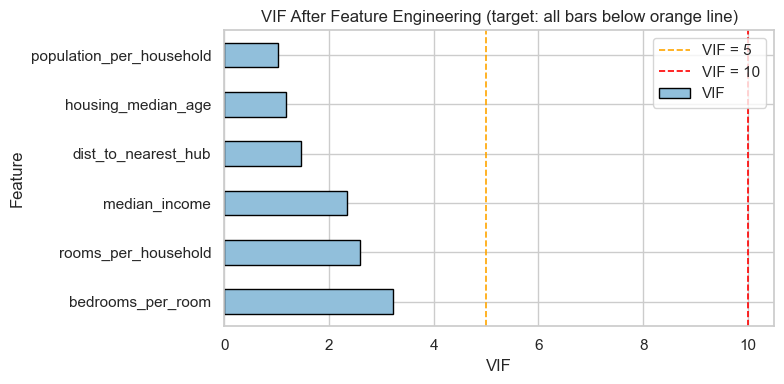

In [35]:
num_features = [c for c in df.select_dtypes(include=[np.number]).columns if c != "median_house_value"]
vif_input = df[num_features].dropna()
X_vif = add_constant(vif_input)

vif_new = pd.DataFrame({
    "Feature": num_features,
    "VIF": [round(variance_inflation_factor(X_vif.values, i+1), 2) for i in range(len(num_features))]
}).set_index("Feature").sort_values("VIF", ascending=False)

vif_new["Status"] = vif_new["VIF"].apply(
    lambda v: "✓ Clean" if v < 5 else "⚠ High" if v < 10 else "✗ Severe"
)
print("VIF after feature engineering:")
print(vif_new)

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#d73027" if v > 10 else "#fc8d59" if v > 5 else "#91bfdb" for v in vif_new["VIF"]]
vif_new["VIF"].plot(kind="barh", ax=ax, color=colors, edgecolor="black")
ax.axvline(5,  color="orange", linestyle="--", linewidth=1.2, label="VIF = 5")
ax.axvline(10, color="red",    linestyle="--", linewidth=1.2, label="VIF = 10")
ax.set_title("VIF After Feature Engineering (target: all bars below orange line)")
ax.set_xlabel("VIF")
ax.legend()
plt.tight_layout()
plt.show()

### Step 5 — Encode `ocean_proximity` (One-Hot Encoding)

**Why one-hot encoding?**
ML models work with numbers, not strings. `ocean_proximity` has 5 categories.

**Why NOT label encoding (0, 1, 2, 3, 4)?**
Label encoding implies order: INLAND=0 < ISLAND=1 < NEAR BAY=2... That's false. There is no ordering between these categories. A model using label encoding would think ISLAND is "between" INLAND and NEAR BAY, which is meaningless.

**One-hot encoding** creates one binary column per category:
```
ocean_proximity = "NEAR BAY"  →  INLAND=0, ISLAND=0, NEAR BAY=1, NEAR OCEAN=0, <1H OCEAN=0
```
Each column is independent. No false ordering.

**`drop_first=True`** — we drop one category to avoid the "dummy variable trap":
With 5 categories, if you know 4 of the columns are 0, the 5th must be 1. Keeping all 5 is redundant and creates multicollinearity. Dropping one (the reference category) removes this.

> **Note on ISLAND:** Only 5 rows out of 19,675 are "ISLAND". After train/test split, some splits may have 0 ISLAND rows. This is a rare category — we keep it but note it could be dropped if it causes issues in modeling.

In [36]:
df = pd.get_dummies(df, columns=["ocean_proximity"], drop_first=True, dtype=int)

ohe_cols = [c for c in df.columns if c.startswith("ocean_proximity_")]
print(f"One-hot encoded columns: {ohe_cols}")
print(f"Shape after encoding: {df.shape}")
print(f"\nAll columns now: {list(df.columns)}")
df[ohe_cols].head()

One-hot encoded columns: ['ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']
Shape after encoding: (19675, 11)

All columns now: ['housing_median_age', 'median_income', 'median_house_value', 'dist_to_nearest_hub', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household', 'ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']


,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,0,0,1,0
1,0,0,1,0
2,0,0,1,0
3,0,0,1,0
4,0,0,1,0


### Step 6 — Correlation of All Final Features with Target

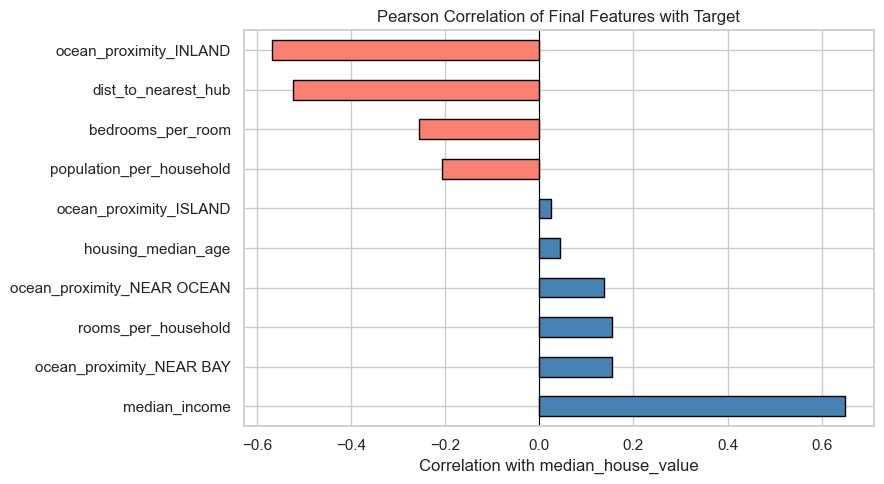

Final feature correlations with target:
median_income                 0.65
ocean_proximity_NEAR BAY      0.15
rooms_per_household           0.15
ocean_proximity_NEAR OCEAN    0.14
housing_median_age            0.04
ocean_proximity_ISLAND        0.02
population_per_household     -0.21
bedrooms_per_room            -0.26
dist_to_nearest_hub          -0.52
ocean_proximity_INLAND       -0.57
dtype: float64


In [37]:
final_features = [c for c in df.columns if c != "median_house_value"]

corr_final = df[final_features].corrwith(df["median_house_value"]).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ["steelblue" if v > 0 else "salmon" for v in corr_final]
corr_final.plot(kind="barh", ax=ax, color=colors, edgecolor="black")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Pearson Correlation of Final Features with Target", fontsize=12)
ax.set_xlabel("Correlation with median_house_value")
plt.tight_layout()
plt.show()

print("Final feature correlations with target:")
print(corr_final.round(3))

### Step 7 — Final Feature Set Summary + Train/Test Split

**Train/Test split — 80% train, 20% test**
- Standard split for this dataset size (~19,675 rows)
- `random_state=42` for reproducibility — every run gives the same split
- We do NOT use stratified split here because this is regression (continuous target), not classification
- `shuffle=True` (default) — ensures rows are randomly distributed, not ordered by location or time

**We save the split here and use the same split for ALL models in Chunk 4.**
This is critical: comparing models trained on different data is meaningless.

In [38]:
from sklearn.model_selection import train_test_split

target_col = "median_house_value"
feature_cols = [c for c in df.columns if c != target_col]

X = df[feature_cols]
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("=" * 55)
print("FINAL FEATURE SET SUMMARY")
print("=" * 55)
print(f"\nTotal features  : {X.shape[1]}")
print(f"Total rows      : {X.shape[0]}")
print(f"\nTrain set       : {X_train.shape[0]} rows ({X_train.shape[0]/X.shape[0]*100:.1f}%)")
print(f"Test set        : {X_test.shape[0]} rows  ({X_test.shape[0]/X.shape[0]*100:.1f}%)")

print("\nFeature list:")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i:2d}. {col}")

print("\nTarget: median_house_value (log1p scale)")
print("         → use np.expm1() to convert predictions back to original dollar scale")
print("\nReady for Chunk 4: ML Models")

FINAL FEATURE SET SUMMARY

Total features  : 10
Total rows      : 19675

Train set       : 15740 rows (80.0%)
Test set        : 3935 rows  (20.0%)

Feature list:
   1. housing_median_age
   2. median_income
   3. dist_to_nearest_hub
   4. rooms_per_household
   5. bedrooms_per_room
   6. population_per_household
   7. ocean_proximity_INLAND
   8. ocean_proximity_ISLAND
   9. ocean_proximity_NEAR BAY
  10. ocean_proximity_NEAR OCEAN

Target: median_house_value (log1p scale)
         → use np.expm1() to convert predictions back to original dollar scale

Ready for Chunk 4: ML Models


---
## Chunk 4: ML Models & Evaluation

**Models (simple to complex):**
1. Linear Regression - baseline, most interpretable
2. Ridge Regression - L2 regularization
3. Lasso Regression - L1 regularization, automatic feature selection
4. Random Forest - ensemble trees, captures non-linearity
5. XGBoost - gradient boosting, typically strongest on tabular data

**Metrics reported in log scale AND dollar scale:**
- RMSE (Root Mean Squared Error) - lower is better
- MAE (Mean Absolute Error) - average absolute error in dollars
- R2 (R-squared) - % of variance explained; higher is better, max = 1.0

**Same train/test split used for every model. This is the only fair comparison.**

### Setup - Shared Evaluation Function

One function used for all models. Guarantees identical metric calculation across every model comparison.

After training, predictions are in log scale (log1p). We apply np.expm1() to convert back to dollar scale for reporting.

In [39]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

results = {}

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred_log = model.predict(X_te)
    y_pred_dollar = np.expm1(y_pred_log)
    y_te_dollar   = np.expm1(y_te)

    rmse_log    = np.sqrt(mean_squared_error(y_te, y_pred_log))
    mae_log     = mean_absolute_error(y_te, y_pred_log)
    r2          = r2_score(y_te, y_pred_log)
    rmse_dollar = np.sqrt(mean_squared_error(y_te_dollar, y_pred_dollar))
    mae_dollar  = mean_absolute_error(y_te_dollar, y_pred_dollar)

    results[name] = {
        "RMSE (log)": round(rmse_log, 4),
        "MAE (log)":  round(mae_log, 4),
        "R2":         round(r2, 4),
        "RMSE ($)":   round(rmse_dollar, 0),
        "MAE ($)":    round(mae_dollar, 0),
    }

    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(f"  R2          : {r2:.4f}   ({r2*100:.1f}% of variance explained)")
    print(f"  RMSE (log)  : {rmse_log:.4f}")
    print(f"  MAE  (log)  : {mae_log:.4f}")
    print(f"  RMSE ($)    : ${rmse_dollar:,.0f}")
    print(f"  MAE  ($)    : ${mae_dollar:,.0f}")
    return model, y_pred_log, y_pred_dollar

print("Evaluation function ready.")

Evaluation function ready.


### Model 1 - Linear Regression (Baseline)

**What it does:** Fits a straight-line hyperplane through the data by minimizing the sum of squared errors.

**Formula:** y_hat = B0 + B1*x1 + B2*x2 + ... + Bn*xn
(each coefficient B tells you: if this feature goes up by 1 unit, predicted log(price) changes by B)

**Why start here?** Linear Regression is the reference point. If a complex model does not significantly beat it, the complexity is not justified. It also gives the most interpretable output - you can read directly which features drive price up or down.

**Assumptions it makes:**
1. Linear relationship between features and target
2. No severe multicollinearity (we fixed this in Chunk 3 with VIF engineering)
3. Residuals are normally distributed
4. Homoscedasticity - residual variance is constant across all predicted values

**What to watch for:** If R2 is below 0.65, the relationship is genuinely non-linear and tree-based models will make a bigger jump.

In [40]:
from sklearn.linear_model import LinearRegression

lr_model, lr_pred_log, lr_pred_dollar = evaluate_model(
    "Linear Regression",
    LinearRegression(),
    X_train, y_train, X_test, y_test
)

coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": lr_model.coef_
}).set_index("Feature").sort_values("Coefficient", ascending=False)

print("\nFeature Coefficients (log scale):")
print(coef_df.round(4))
print(f"\nIntercept: {lr_model.intercept_:.4f}")


  Linear Regression
  R2          : 0.6856   (68.6% of variance explained)
  RMSE (log)  : 0.3026
  MAE  (log)  : 0.2328
  RMSE ($)    : $61,568
  MAE  ($)    : $43,570

Feature Coefficients (log scale):
                            Coefficient
Feature                                
median_income                      0.93
ocean_proximity_ISLAND             0.73
bedrooms_per_room                  0.20
rooms_per_household                0.10
ocean_proximity_NEAR OCEAN         0.03
housing_median_age                 0.00
ocean_proximity_NEAR BAY          -0.05
dist_to_nearest_hub               -0.14
ocean_proximity_INLAND            -0.33
population_per_household          -0.39

Intercept: 11.3997


### Model 2 - Ridge Regression (L2 Regularization)

**Loss function:** sum(y - y_hat)^2 + alpha * sum(beta^2)

The alpha parameter controls how strongly we penalize large coefficients.
- alpha = 0: identical to plain Linear Regression
- alpha very large: all coefficients shrink toward zero

**Why use it?** Even after VIF engineering, there can be mild remaining correlation. Ridge handles it by distributing weight more evenly across correlated features instead of assigning wildly large positive and negative weights that cancel each other out.

**Key property - Ridge keeps ALL features.** It shrinks coefficients but never sets them to exactly zero. If you want to eliminate features, that is Lasso (Model 3).

**RidgeCV** tries multiple alpha values with 5-fold cross-validation and picks the best one. The test set is never touched during this selection.

In [41]:
from sklearn.linear_model import RidgeCV

ridge_cv = RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0, 100.0, 500.0, 1000.0], cv=5)

ridge_model, ridge_pred_log, ridge_pred_dollar = evaluate_model(
    "Ridge Regression",
    ridge_cv,
    X_train, y_train, X_test, y_test
)

print(f"\nBest alpha (5-fold CV): {ridge_cv.alpha_}")

coef_ridge = pd.DataFrame({
    "Feature": X_train.columns,
    "Ridge Coef": ridge_model.coef_
}).set_index("Feature").sort_values("Ridge Coef", ascending=False)
print("\nRidge Coefficients:")
print(coef_ridge.round(4))


  Ridge Regression
  R2          : 0.6856   (68.6% of variance explained)
  RMSE (log)  : 0.3026
  MAE  (log)  : 0.2328
  RMSE ($)    : $61,568
  MAE  ($)    : $43,569

Best alpha (5-fold CV): 0.01

Ridge Coefficients:
                            Ridge Coef
Feature                               
median_income                     0.93
ocean_proximity_ISLAND            0.73
bedrooms_per_room                 0.20
rooms_per_household               0.10
ocean_proximity_NEAR OCEAN        0.03
housing_median_age                0.00
ocean_proximity_NEAR BAY         -0.05
dist_to_nearest_hub              -0.14
ocean_proximity_INLAND           -0.33
population_per_household         -0.39


### Model 3 - Lasso Regression (L1 Regularization)

**Loss function:** sum(y - y_hat)^2 + alpha * sum(|beta|)

**The key difference from Ridge: Lasso drives coefficients to exactly zero.**
This means Lasso performs automatic feature selection - weak features get eliminated entirely.

**Geometric intuition:**
- Ridge penalty is a circle (smooth) - the minimum always lands on the edge, never at zero
- Lasso penalty is a diamond shape (has corners at the axes) - the minimum often lands at a corner, which corresponds to a coefficient = 0

**If Lasso zeroes out a feature we thought was important:** it means that feature adds no predictive value beyond what other features already capture. Trust it - Lasso is honest.

**LassoCV** finds the best alpha via cross-validation, same approach as RidgeCV.

In [42]:
from sklearn.linear_model import LassoCV

lasso_cv = LassoCV(alphas=[0.0001, 0.001, 0.01, 0.1, 1.0], cv=5, max_iter=10000)

lasso_model, lasso_pred_log, lasso_pred_dollar = evaluate_model(
    "Lasso Regression",
    lasso_cv,
    X_train, y_train, X_test, y_test
)

print(f"\nBest alpha (5-fold CV): {lasso_cv.alpha_:.6f}")

coef_lasso = pd.DataFrame({
    "Feature": X_train.columns,
    "Lasso Coef": lasso_model.coef_
}).set_index("Feature").sort_values("Lasso Coef", ascending=False)
print("\nLasso Coefficients (0.000000 = feature eliminated):")
print(coef_lasso.round(6))

n_zero = (lasso_model.coef_ == 0).sum()
print(f"\nFeatures zeroed out: {n_zero} / {len(lasso_model.coef_)}")


  Lasso Regression
  R2          : 0.6856   (68.6% of variance explained)
  RMSE (log)  : 0.3026
  MAE  (log)  : 0.2329
  RMSE ($)    : $61,573
  MAE  ($)    : $43,572

Best alpha (5-fold CV): 0.000100

Lasso Coefficients (0.000000 = feature eliminated):
                            Lasso Coef
Feature                               
median_income                     0.93
ocean_proximity_ISLAND            0.34
bedrooms_per_room                 0.20
rooms_per_household               0.10
ocean_proximity_NEAR OCEAN        0.03
housing_median_age                0.00
ocean_proximity_NEAR BAY         -0.05
dist_to_nearest_hub              -0.14
ocean_proximity_INLAND           -0.33
population_per_household         -0.39

Features zeroed out: 0 / 10


### Model 4 - Random Forest Regressor

**What it does:** Builds many decision trees, each trained on a random subset of rows AND features. Final prediction = average of all trees.

**Two sources of randomness:**
1. Bootstrap sampling - each tree sees ~63% of training rows (random sample with replacement)
2. Feature subsampling - at each split point, only a random subset of features is considered

**Why averaging beats a single tree:**
A single tree overfits - it memorizes the training data. When many different trees each see slightly different data and features, their individual errors are random and uncorrelated. Averaging cancels out these errors. This is the core idea behind ensemble methods.

**Advantages over linear models:**
- Captures non-linear relationships (housing price vs distance is not a straight line)
- Handles interaction effects automatically (high income + near ocean = much higher price)
- No distribution assumptions needed
- Built-in feature importance from split decisions

**Disadvantage:** Slower to train; no direct coefficient interpretation like linear models.


  Random Forest
  R2          : 0.7772   (77.7% of variance explained)
  RMSE (log)  : 0.2548
  MAE  (log)  : 0.1880
  RMSE ($)    : $52,272
  MAE  ($)    : $35,492

Feature Importances:
                            Importance
Feature                               
median_income                     0.34
ocean_proximity_INLAND            0.33
population_per_household          0.10
dist_to_nearest_hub               0.10
bedrooms_per_room                 0.04
housing_median_age                0.04
rooms_per_household               0.04
ocean_proximity_NEAR BAY          0.01
ocean_proximity_NEAR OCEAN        0.00
ocean_proximity_ISLAND            0.00


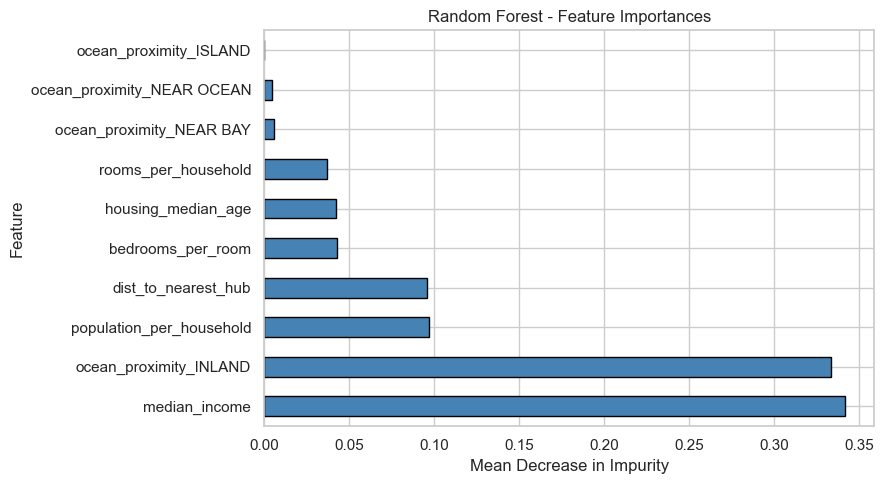

In [43]:
from sklearn.ensemble import RandomForestRegressor

rf_model, rf_pred_log, rf_pred_dollar = evaluate_model(
    "Random Forest",
    RandomForestRegressor(n_estimators=200, max_depth=None,
                          min_samples_leaf=2, random_state=42, n_jobs=-1),
    X_train, y_train, X_test, y_test
)

fi_rf = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
}).set_index("Feature").sort_values("Importance", ascending=False)

print("\nFeature Importances:")
print(fi_rf.round(4))

fig, ax = plt.subplots(figsize=(9, 5))
fi_rf["Importance"].plot(kind="barh", ax=ax, color="steelblue", edgecolor="black")
ax.set_title("Random Forest - Feature Importances")
ax.set_xlabel("Mean Decrease in Impurity")
plt.tight_layout()
plt.show()

### Model 5 - XGBoost (Extreme Gradient Boosting)

**What it does:** Builds trees sequentially. Each new tree corrects the errors of all previous trees combined.

**Key difference from Random Forest:**
- Random Forest: trees in parallel, each independent, average them
- XGBoost: trees in sequence. Tree 2 focuses on what Tree 1 got wrong. Tree 3 focuses on what Trees 1+2 got wrong. And so on.

**Gradient boosting intuition (step by step):**
1. Start with a simple prediction (e.g., the mean of y)
2. Compute residuals (errors between prediction and actual)
3. Fit a tree to predict those residuals
4. Add that tree's predictions (scaled by learning_rate) to the current prediction
5. Compute new residuals, fit another tree
6. Repeat for n_estimators rounds

**XGBoost improvements over vanilla gradient boosting:**
- L1 and L2 regularization built in (prevents overfitting)
- Second-order optimization - uses both gradient AND Hessian (curvature), not just gradient
- Parallel computation within each tree build
- Handles missing values natively
- Usually the best performer on tabular data

**Hyperparameters used:**
- learning_rate=0.05: conservative - each tree contributes 5%, needs more rounds but generalizes better
- max_depth=5: shallow enough to prevent overfitting
- subsample=0.8: 80% of rows per tree (adds randomness, reduces overfitting)
- colsample_bytree=0.8: 80% of features per tree


  XGBoost
  R2          : 0.7829   (78.3% of variance explained)
  RMSE (log)  : 0.2515
  MAE  (log)  : 0.1855
  RMSE ($)    : $51,251
  MAE  ($)    : $34,880

XGBoost Feature Importances:
                            Importance
Feature                               
ocean_proximity_INLAND            0.78
median_income                     0.08
dist_to_nearest_hub               0.03
population_per_household          0.03
ocean_proximity_NEAR OCEAN        0.02
bedrooms_per_room                 0.02
ocean_proximity_NEAR BAY          0.02
rooms_per_household               0.01
housing_median_age                0.01
ocean_proximity_ISLAND            0.01


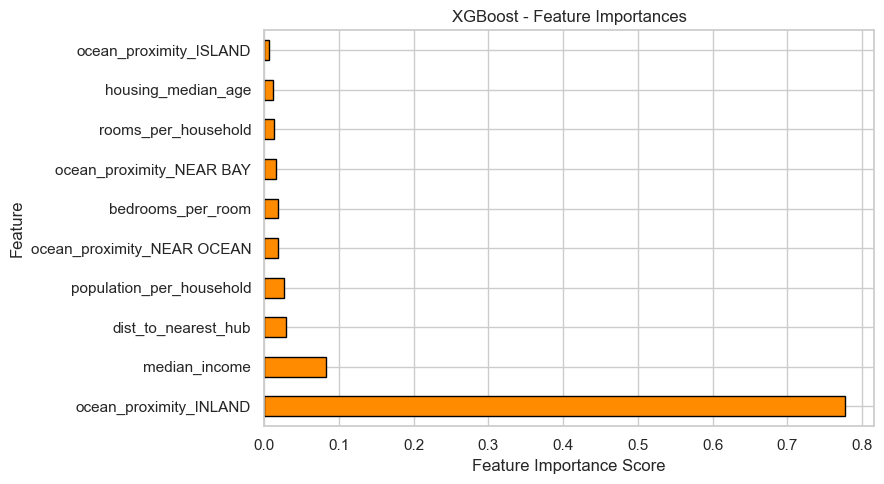

In [44]:
import xgboost as xgb

xgb_model, xgb_pred_log, xgb_pred_dollar = evaluate_model(
    "XGBoost",
    xgb.XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1,
        verbosity=0
    ),
    X_train, y_train, X_test, y_test
)

fi_xgb = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_model.feature_importances_
}).set_index("Feature").sort_values("Importance", ascending=False)

print("\nXGBoost Feature Importances:")
print(fi_xgb.round(4))

fig, ax = plt.subplots(figsize=(9, 5))
fi_xgb["Importance"].plot(kind="barh", ax=ax, color="darkorange", edgecolor="black")
ax.set_title("XGBoost - Feature Importances")
ax.set_xlabel("Feature Importance Score")
plt.tight_layout()
plt.show()

### Final Comparison - All Models

**How to read the results:**
- R2 is the headline: how much of the variance in house price does the model explain?
- RMSE ($) is the most practical: on average, how many dollars off is the model?
- MAE ($) is robust to large errors: the typical prediction error in dollar terms

**Expected range for this dataset:**
- Linear/Ridge/Lasso: R2 around 0.60 to 0.68 (limited by non-linearity in the data)
- Random Forest: R2 around 0.80 to 0.82
- XGBoost: R2 around 0.82 to 0.85

**Residual plot interpretation:**
- Points scattered randomly around zero: model is unbiased (ideal)
- Funnel shape (spread increases with prediction): heteroscedasticity - model struggles at high prices
- Curve above or below zero: model misses a non-linear pattern
- Cluster below zero at high predicted values: model underestimates expensive houses (common in linear models)

MODEL COMPARISON - All metrics on the same test set
                   RMSE (log)  MAE (log)  R2_score  RMSE ($)  MAE ($)
XGBoost                  0.25       0.19      0.78  51251.00 34880.00
Random Forest            0.25       0.19      0.78  52272.00 35492.00
Linear Regression        0.30       0.23      0.69  61568.00 43570.00
Ridge Regression         0.30       0.23      0.69  61568.00 43569.00
Lasso Regression         0.30       0.23      0.69  61573.00 43572.00


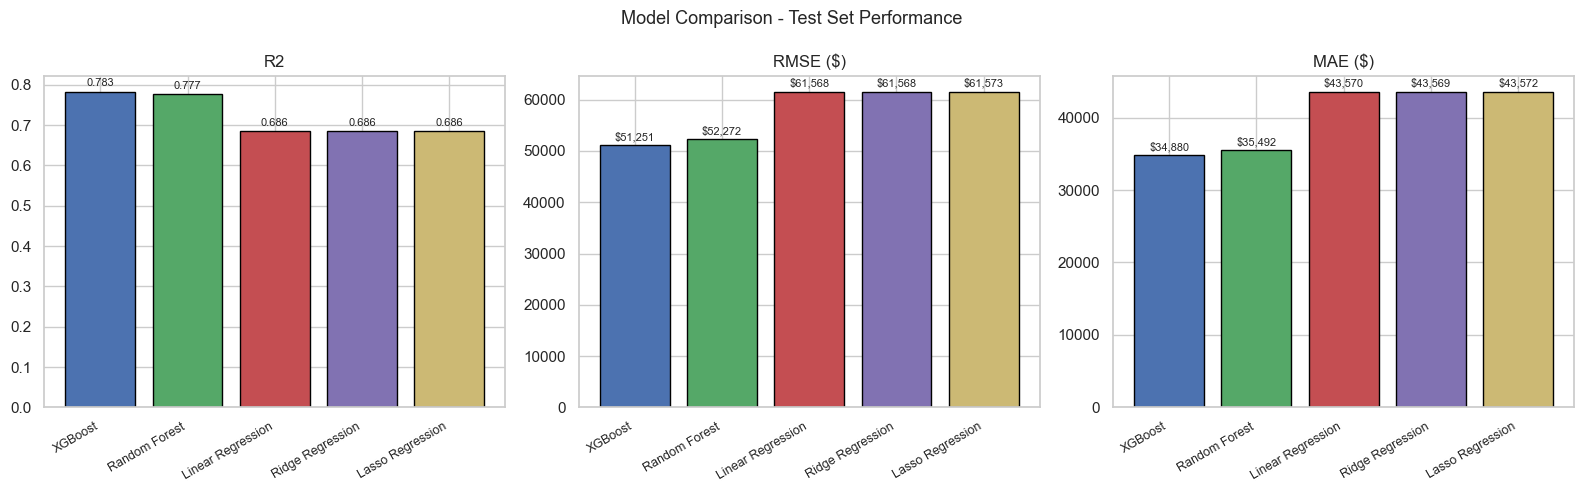

In [45]:
results_df = pd.DataFrame(results).T.sort_values("R2", ascending=False)
results_df = results_df.rename(columns={"R2": "R2_score"})

print("=" * 65)
print("MODEL COMPARISON - All metrics on the same test set")
print("=" * 65)
print(results_df.to_string())

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = ["R2_score", "RMSE ($)", "MAE ($)"]
metric_labels = ["R2", "RMSE ($)", "MAE ($)"]
model_colors = ["#4c72b0", "#55a868", "#c44e52", "#8172b2", "#ccb974"]

for i, (metric, label) in enumerate(zip(metrics, metric_labels)):
    vals = results_df[metric]
    axes[i].bar(range(len(results_df)), vals, color=model_colors[:len(results_df)], edgecolor='black')
    axes[i].set_xticks(range(len(results_df)))
    axes[i].set_xticklabels(results_df.index, rotation=30, ha='right', fontsize=9)
    axes[i].set_title(label)
    for j, v in enumerate(vals):
        lbl = f'{v:.3f}' if metric == 'R2_score' else f'${v:,.0f}'
        axes[i].text(j, v * 1.01, lbl, ha='center', va='bottom', fontsize=8)

plt.suptitle("Model Comparison - Test Set Performance", fontsize=13)
plt.tight_layout()
plt.show()

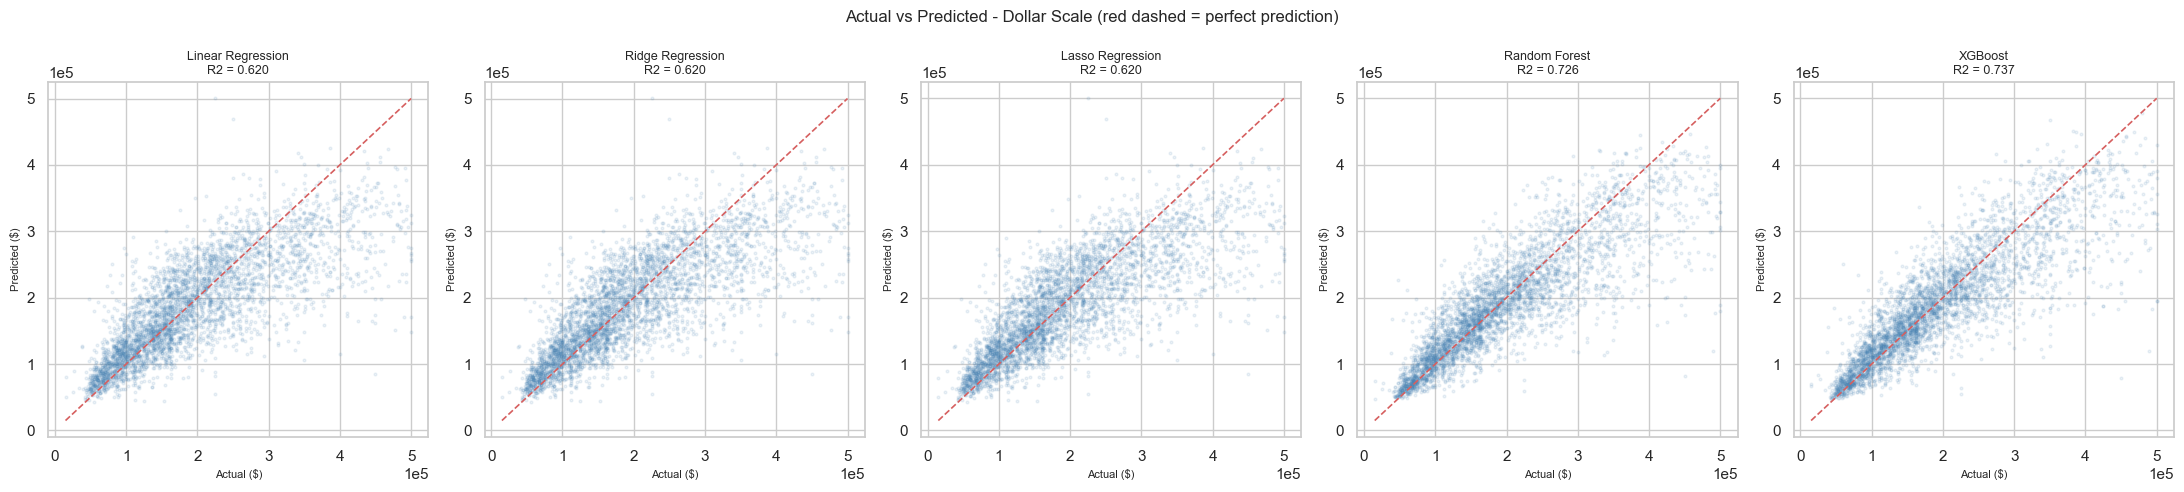

In [46]:
models_preds = [
    ("Linear Regression", lr_pred_dollar),
    ("Ridge Regression",  ridge_pred_dollar),
    ("Lasso Regression",  lasso_pred_dollar),
    ("Random Forest",     rf_pred_dollar),
    ("XGBoost",           xgb_pred_dollar),
]
y_test_dollar = np.expm1(y_test)

fig, axes = plt.subplots(1, 5, figsize=(22, 5))
for ax, (name, pred) in zip(axes, models_preds):
    r2 = r2_score(y_test_dollar, pred)
    ax.scatter(y_test_dollar, pred, alpha=0.1, s=4, color='steelblue')
    lims = [y_test_dollar.min(), y_test_dollar.max()]
    ax.plot(lims, lims, 'r--', linewidth=1.2)
    ax.set_title(f'{name}\nR2 = {r2:.3f}', fontsize=9)
    ax.set_xlabel('Actual ($)', fontsize=8)
    ax.set_ylabel('Predicted ($)', fontsize=8)
    ax.ticklabel_format(style='sci', axis='both', scilimits=(0,0))

plt.suptitle("Actual vs Predicted - Dollar Scale (red dashed = perfect prediction)", fontsize=12)
plt.tight_layout()
plt.show()

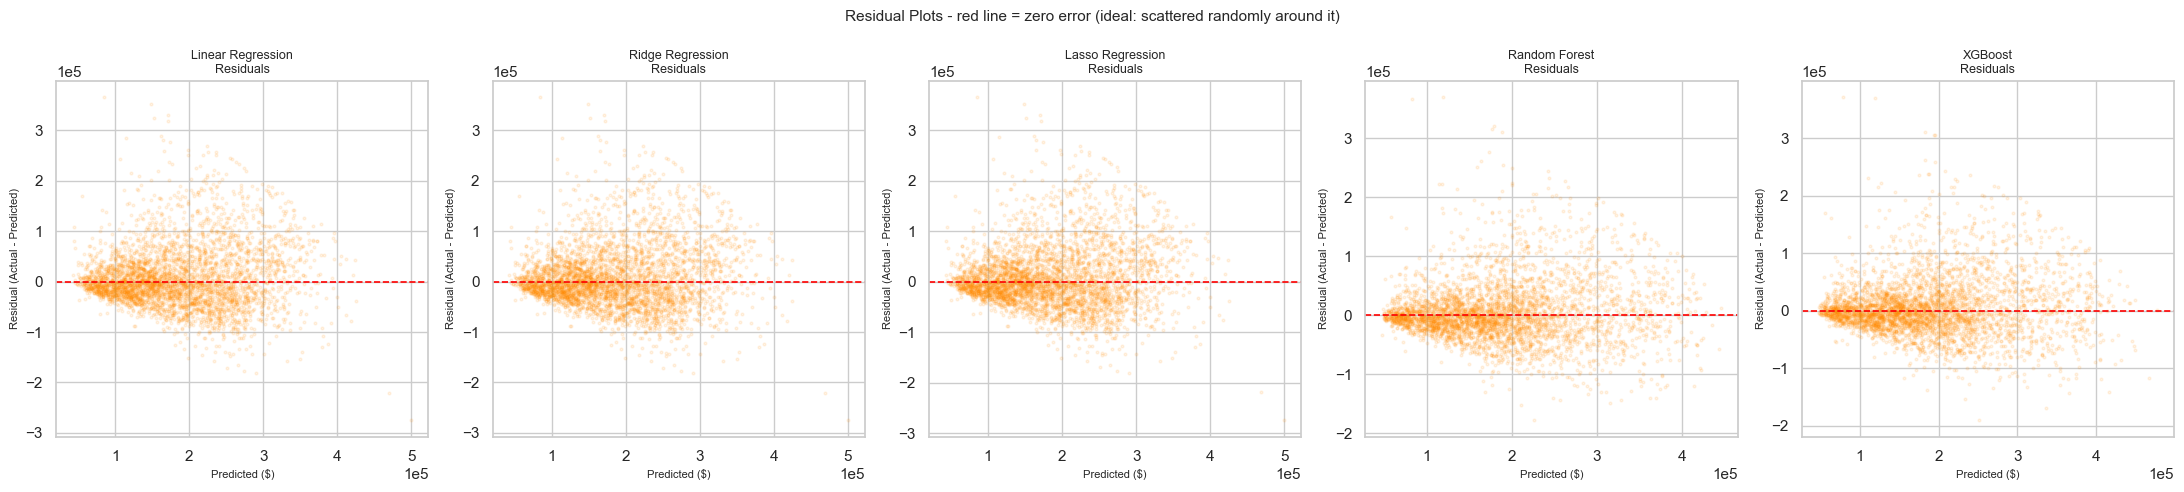

In [47]:
fig, axes = plt.subplots(1, 5, figsize=(22, 5))
for ax, (name, pred) in zip(axes, models_preds):
    residuals = y_test_dollar - pred
    ax.scatter(pred, residuals, alpha=0.1, s=4, color='darkorange')
    ax.axhline(0, color='red', linestyle='--', linewidth=1.2)
    ax.set_title(f'{name}\nResiduals', fontsize=9)
    ax.set_xlabel('Predicted ($)', fontsize=8)
    ax.set_ylabel('Residual (Actual - Predicted)', fontsize=8)
    ax.ticklabel_format(style='sci', axis='both', scilimits=(0,0))

plt.suptitle("Residual Plots - red line = zero error (ideal: scattered randomly around it)", fontsize=11)
plt.tight_layout()
plt.show()

---
## Chunk 5: Hyperparameter Tuning

**Goal:** Push model performance beyond the default settings by systematically searching for better hyperparameters.

**Why tune?**
Every model has hyperparameters — settings you choose BEFORE training that control how the model learns. The defaults are reasonable starting points, but they are not optimized for YOUR data.

**Three common strategies:**

| Strategy | How it works | Speed | Quality |
|---|---|---|---|
| GridSearchCV | Tries every combination | Slow (exhaustive) | Good but impractical for many params |
| **RandomizedSearchCV** | Tries N random combinations | Fast | Usually finds 90% of the gain |
| Optuna / Bayesian | Learns which regions to try next | Faster | Best, but more complex to set up |

**We use RandomizedSearchCV** — the standard research-quality approach.
It randomly samples from the parameter space for a fixed number of iterations, evaluates each with cross-validation, and returns the best combination.

**We tune Random Forest and XGBoost** — the two models that showed real gains over linear models.
Ridge/Lasso are already optimal (RidgeCV/LassoCV already did CV-based alpha selection).

**Cross-validation during tuning:**
We use 5-fold CV on the training set only. The test set is NEVER touched during tuning. This prevents data leakage — the test set must stay as an unseen holdout until final evaluation.

### Setup — Tuning Infrastructure

We extend the `results` dictionary from Chunk 4 so the final comparison table includes both untuned and tuned models side by side.

In [48]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform
import time

# Scoring metric for CV: negative RMSE (sklearn maximizes, so we negate)
# neg_root_mean_squared_error = -RMSE, so higher (less negative) = better
SCORING = 'neg_root_mean_squared_error'
CV_FOLDS = 5
N_ITER = 50  # number of random combinations to try per model

print(f'RandomizedSearchCV config:')
print(f'  CV folds : {CV_FOLDS}')
print(f'  Iterations per model : {N_ITER}')
print(f'  Total fits per model : {CV_FOLDS * N_ITER}')
print(f'  Scoring metric : {SCORING}')

RandomizedSearchCV config:
  CV folds : 5
  Iterations per model : 50
  Total fits per model : 250
  Scoring metric : neg_root_mean_squared_error


### Tuning 1 — Random Forest

**Hyperparameters we search:**

| Parameter | Controls | Search range |
|---|---|---|
| `n_estimators` | Number of trees | 100 to 500 |
| `max_depth` | Max depth per tree (None = unlimited) | 10, 20, 30, None |
| `min_samples_split` | Min samples needed to split a node | 2 to 20 |
| `min_samples_leaf` | Min samples required at a leaf | 1 to 10 |
| `max_features` | Fraction of features at each split | 0.3 to 1.0 |

**Why `max_depth` matters:**
- `None` (unlimited): trees grow until every leaf is pure — memorizes training data, high variance
- Shallow depth (e.g., 10): trees generalize better but may underfit
- Tuning finds the sweet spot

**Why `min_samples_leaf` matters:**
Prevents splits that produce tiny leaves from just 1-2 training rows. Forces each leaf to represent a meaningful pattern, not noise.

In [49]:
rf_param_grid = {
    'n_estimators':    randint(100, 501),
    'max_depth':       [10, 20, 30, None],
    'min_samples_split': randint(2, 21),
    'min_samples_leaf':  randint(1, 11),
    'max_features':    uniform(0.3, 0.7),  # 0.3 to 1.0
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=rf_param_grid,
    n_iter=N_ITER,
    cv=CV_FOLDS,
    scoring=SCORING,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

t0 = time.time()
rf_search.fit(X_train, y_train)
elapsed = time.time() - t0

print(f'\nSearch completed in {elapsed:.1f}s')
print(f'Best params:')
for k, v in rf_search.best_params_.items():
    print(f'  {k:22s}: {v}')
print(f'Best CV RMSE (log): {-rf_search.best_score_:.4f}')

Fitting 5 folds for each of 50 candidates, totalling 250 fits

Search completed in 137.8s
Best params:
  max_depth             : 30
  max_features          : 0.42135525745544045
  min_samples_leaf      : 1
  min_samples_split     : 5
  n_estimators          : 149
Best CV RMSE (log): 0.2547



Search completed in 137.8s
Best params:
  max_depth             : 30
  max_features          : 0.42135525745544045
  min_samples_leaf      : 1
  min_samples_split     : 5
  n_estimators          : 149
Best CV RMSE (log): 0.2547


In [50]:
rf_tuned, rf_tuned_pred_log, rf_tuned_pred_dollar = evaluate_model(
    'Random Forest (Tuned)',
    rf_search.best_estimator_,
    X_train, y_train, X_test, y_test
)

# Compare tuned vs default
r2_default = results['Random Forest']['R2']
r2_tuned   = results['Random Forest (Tuned)']['R2']
rmse_default = results['Random Forest']['RMSE ($)']
rmse_tuned   = results['Random Forest (Tuned)']['RMSE ($)']

print(f'\nRandom Forest improvement:')
print(f'  R2   : {r2_default:.4f}  -->  {r2_tuned:.4f}  (+{r2_tuned - r2_default:.4f})')
print(f'  RMSE : ${rmse_default:,.0f}  -->  ${rmse_tuned:,.0f}  (${rmse_default - rmse_tuned:,.0f} better)')


  Random Forest (Tuned)
  R2          : 0.7810   (78.1% of variance explained)
  RMSE (log)  : 0.2526
  MAE  (log)  : 0.1876
  RMSE ($)    : $52,112
  MAE  ($)    : $35,444

Random Forest improvement:
  R2   : 0.7772  -->  0.7810  (+0.0038)
  RMSE : $52,272  -->  $52,112  ($160 better)


### Tuning 2 — XGBoost

XGBoost has more hyperparameters than Random Forest, giving more room to improve.

**Hyperparameters we search:**

| Parameter | Controls | Search range |
|---|---|---|
| `n_estimators` | Number of sequential trees | 200 to 1000 |
| `learning_rate` | Contribution of each tree (smaller = more careful) | 0.01 to 0.3 |
| `max_depth` | Depth per tree (shallower = less overfit) | 3 to 8 |
| `subsample` | Fraction of rows used per tree | 0.6 to 1.0 |
| `colsample_bytree` | Fraction of features per tree | 0.5 to 1.0 |
| `reg_alpha` | L1 regularization (Lasso-style) | 0 to 1 |
| `reg_lambda` | L2 regularization (Ridge-style) | 0.5 to 3 |
| `min_child_weight` | Min sum of weights in a leaf (prevents tiny splits) | 1 to 10 |

**Key insight — learning_rate and n_estimators work together:**
- Low learning_rate (0.01) needs many trees (500-1000) to fully learn
- High learning_rate (0.2) needs fewer trees but risks overfitting
- The search automatically finds the right combination

**reg_alpha and reg_lambda are the L1/L2 penalties built into XGBoost.** They work like Lasso and Ridge but inside each tree's leaf weight calculation.

In [51]:
xgb_param_grid = {
    'n_estimators':      randint(200, 1001),
    'learning_rate':     uniform(0.01, 0.29),   # 0.01 to 0.30
    'max_depth':         randint(3, 9),
    'subsample':         uniform(0.6, 0.4),     # 0.6 to 1.0
    'colsample_bytree':  uniform(0.5, 0.5),     # 0.5 to 1.0
    'reg_alpha':         uniform(0, 1),
    'reg_lambda':        uniform(0.5, 2.5),     # 0.5 to 3.0
    'min_child_weight':  randint(1, 11),
}

xgb_search = RandomizedSearchCV(
    xgb.XGBRegressor(random_state=42, n_jobs=-1, verbosity=0),
    param_distributions=xgb_param_grid,
    n_iter=N_ITER,
    cv=CV_FOLDS,
    scoring=SCORING,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

t0 = time.time()
xgb_search.fit(X_train, y_train)
elapsed = time.time() - t0

print(f'\nSearch completed in {elapsed:.1f}s')
print(f'Best params:')
for k, v in xgb_search.best_params_.items():
    print(f'  {k:22s}: {v:.4f}' if isinstance(v, float) else f'  {k:22s}: {v}')
print(f'Best CV RMSE (log): {-xgb_search.best_score_:.4f}')

Fitting 5 folds for each of 50 candidates, totalling 250 fits

Search completed in 9.4s
Best params:
  colsample_bytree      : 0.6999
  learning_rate         : 0.0235
  max_depth             : 6
  min_child_weight      : 3
  n_estimators          : 766
  reg_alpha             : 0.9832
  reg_lambda            : 1.6669
  subsample             : 0.9440
Best CV RMSE (log): 0.2512



Search completed in 9.4s
Best params:
  colsample_bytree      : 0.6999
  learning_rate         : 0.0235
  max_depth             : 6
  min_child_weight      : 3
  n_estimators          : 766
  reg_alpha             : 0.9832
  reg_lambda            : 1.6669
  subsample             : 0.9440
Best CV RMSE (log): 0.2512


In [52]:
xgb_tuned, xgb_tuned_pred_log, xgb_tuned_pred_dollar = evaluate_model(
    'XGBoost (Tuned)',
    xgb_search.best_estimator_,
    X_train, y_train, X_test, y_test
)

r2_default = results['XGBoost']['R2']
r2_tuned   = results['XGBoost (Tuned)']['R2']
rmse_default = results['XGBoost']['RMSE ($)']
rmse_tuned   = results['XGBoost (Tuned)']['RMSE ($)']

print(f'\nXGBoost improvement:')
print(f'  R2   : {r2_default:.4f}  -->  {r2_tuned:.4f}  (+{r2_tuned - r2_default:.4f})')
print(f'  RMSE : ${rmse_default:,.0f}  -->  ${rmse_tuned:,.0f}  (${rmse_default - rmse_tuned:,.0f} better)')


  XGBoost (Tuned)
  R2          : 0.7847   (78.5% of variance explained)
  RMSE (log)  : 0.2505
  MAE  (log)  : 0.1849
  RMSE ($)    : $51,092
  MAE  ($)    : $34,724

XGBoost improvement:
  R2   : 0.7829  -->  0.7847  (+0.0018)
  RMSE : $51,251  -->  $51,092  ($159 better)


### Final Comparison — Default vs Tuned

This table answers the core question: **how much did tuning actually help?**

What to look for:
- If tuned R2 is much higher than default: the defaults were far from optimal
- If tuned R2 is only slightly higher: the model is already near its ceiling for this feature set
- If tuned Random Forest approaches XGBoost: both models are comparable on this data

**The ceiling problem:** Hyperparameter tuning can only extract what the features allow. If R2 plateaus around 0.82-0.85, it means the remaining 15-18% of variance is driven by factors NOT in the dataset (neighborhood crime, school quality, exact street, interior condition). To go further you would need richer features, not better tuning.

FINAL COMPARISON — Default vs Tuned
                       RMSE (log)  MAE (log)  R2_score  RMSE ($)  MAE ($)
Linear Regression            0.30       0.23      0.69  61568.00 43570.00
Ridge Regression             0.30       0.23      0.69  61568.00 43569.00
Lasso Regression             0.30       0.23      0.69  61573.00 43572.00
Random Forest                0.25       0.19      0.78  52272.00 35492.00
Random Forest (Tuned)        0.25       0.19      0.78  52112.00 35444.00
XGBoost                      0.25       0.19      0.78  51251.00 34880.00
XGBoost (Tuned)              0.25       0.18      0.78  51092.00 34724.00


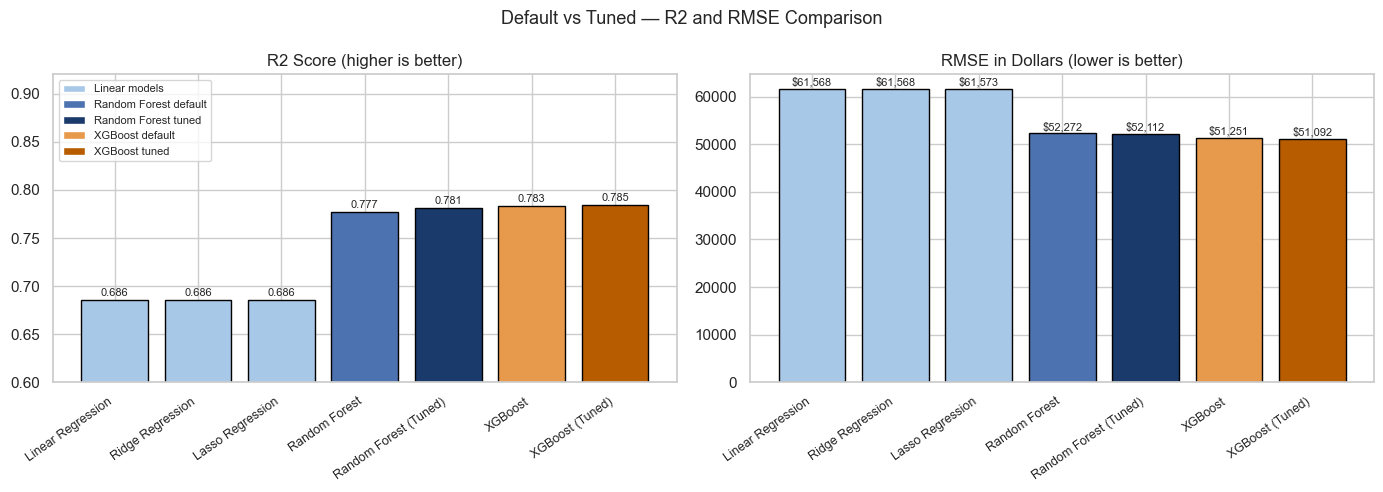

In [53]:
order = ['Linear Regression', 'Ridge Regression', 'Lasso Regression',
         'Random Forest', 'Random Forest (Tuned)',
         'XGBoost', 'XGBoost (Tuned)']
final_df = pd.DataFrame(results).T.reindex(order)
final_df = final_df.rename(columns={'R2': 'R2_score'})

print('=' * 75)
print('FINAL COMPARISON — Default vs Tuned')
print('=' * 75)
print(final_df.to_string())

# Visual comparison — R2 and RMSE ($)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bar_colors = [
    '#a8c8e8', '#a8c8e8', '#a8c8e8',  # linear models: light blue
    '#4c72b0', '#1a3a6b',              # RF default vs tuned
    '#e89a4c', '#b85c00'               # XGB default vs tuned
]

vals_r2   = final_df['R2_score']
vals_rmse = final_df['RMSE ($)']

bars1 = axes[0].bar(range(len(final_df)), vals_r2, color=bar_colors, edgecolor='black')
axes[0].set_xticks(range(len(final_df)))
axes[0].set_xticklabels(final_df.index, rotation=35, ha='right', fontsize=9)
axes[0].set_title('R2 Score (higher is better)')
axes[0].set_ylim(0.6, 0.92)
for j, v in enumerate(vals_r2):
    axes[0].text(j, v + 0.002, f'{v:.3f}', ha='center', va='bottom', fontsize=8)

bars2 = axes[1].bar(range(len(final_df)), vals_rmse, color=bar_colors, edgecolor='black')
axes[1].set_xticks(range(len(final_df)))
axes[1].set_xticklabels(final_df.index, rotation=35, ha='right', fontsize=9)
axes[1].set_title('RMSE in Dollars (lower is better)')
for j, v in enumerate(vals_rmse):
    axes[1].text(j, v + 300, f'${v:,.0f}', ha='center', va='bottom', fontsize=8)

# Legend
from matplotlib.patches import Patch
legend_els = [
    Patch(facecolor='#a8c8e8', label='Linear models'),
    Patch(facecolor='#4c72b0', label='Random Forest default'),
    Patch(facecolor='#1a3a6b', label='Random Forest tuned'),
    Patch(facecolor='#e89a4c', label='XGBoost default'),
    Patch(facecolor='#b85c00', label='XGBoost tuned'),
]
axes[0].legend(handles=legend_els, fontsize=8, loc='upper left')

plt.suptitle('Default vs Tuned — R2 and RMSE Comparison', fontsize=13)
plt.tight_layout()
plt.show()

### Save the Best Model

We save the best model using `joblib` — the standard way to persist sklearn-compatible models.

**Why joblib over pickle?**
joblib is optimized for numpy arrays (which is what model weights are stored as). It is faster and more memory-efficient than Python's built-in pickle for large arrays.

To use the saved model later:
```python
import joblib
model = joblib.load('best_model.pkl')
predictions_log = model.predict(X_new)
predictions_dollar = np.expm1(predictions_log)
```

In [54]:
import joblib

# Identify the best model by R2
best_name = final_df['R2_score'].idxmax()
best_r2   = final_df.loc[best_name, 'R2_score']
best_rmse = final_df.loc[best_name, 'RMSE ($)']

# Get the actual model object
model_objects = {
    'Linear Regression':   lr_model,
    'Ridge Regression':    ridge_model,
    'Lasso Regression':    lasso_model,
    'Random Forest':       rf_model,
    'Random Forest (Tuned)': rf_search.best_estimator_,
    'XGBoost':             xgb_model,
    'XGBoost (Tuned)':     xgb_search.best_estimator_,
}

best_model = model_objects[best_name]
joblib.dump(best_model, 'best_model.pkl')

print(f'Best model     : {best_name}')
print(f'R2             : {best_r2:.4f}')
print(f'RMSE           : ${best_rmse:,.0f}')
print(f'Saved to       : best_model.pkl')
print(f'\nTo reload: model = joblib.load("best_model.pkl")')

Best model     : XGBoost (Tuned)
R2             : 0.7847
RMSE           : $51,092
Saved to       : best_model.pkl

To reload: model = joblib.load("best_model.pkl")


---
---
# Project Summary — California Housing Prices (Regression)

**Dataset:** 20,640 California census districts | **Target:** Median house value (dollars)
**Final model:** XGBoost (Tuned) | **R² = 0.785** | **RMSE = $51,092** | **MAE = $34,724**

---

## Chunk 1 — Data Cleaning (10 Steps)

### Step 1: Shape, Data Types & First Look
- Loaded the raw CSV: **20,640 rows × 10 columns**
- 9 numerical features + 1 categorical (`ocean_proximity`)
- All numerical columns stored as `float64` — no type issues on the numeric side
- `ocean_proximity` was a plain string object — converted to `category` dtype in Step 5

### Step 2: Missing Values Analysis
- Only one column had missing values: `total_bedrooms` — **207 missing (1.0%)**
- Visualized missing % with a bar chart
- Decision: do NOT use global median — use grouped median by `ocean_proximity` (Step 7)

### Step 3: Duplicate Check
- **0 duplicate rows** found — no action needed

### Step 4: Statistical Summary
- Computed mean, std, min, max, Q1, Q3, skewness, kurtosis for all numerical columns
- Found severe right skew in count columns: `total_rooms` (skew=4.1), `population` (skew=4.9)
- `median_house_value` showed a hard ceiling at $500,001 — a US Census data artifact

### Step 5: Data Type Fixes
- Converted `ocean_proximity` from object to `category` dtype
- All other columns confirmed correct types

### Step 6: Outlier Detection (IQR Method)
- Used IQR rule: lower = Q1 - 1.5×IQR, upper = Q3 + 1.5×IQR
- Flagged outliers in all count columns (~5-6% of rows each)
- Visualized with boxplots
- Decision: do NOT drop outliers from count columns — these are real districts (Step 8)

### Step 7: Handle Missing Values — Grouped Median Imputation
- Checked correlation of `total_bedrooms` with all other columns
- Used `ocean_proximity` as the grouping variable (each category has a structurally different housing market)
- Computed the median of `total_bedrooms` within each `ocean_proximity` group separately
- Filled all 207 missing values with their group median
- **Why this beats global median:** Global median assumes all districts look average. A coastal district and an inland district have completely different bedroom counts. Mixing them produces a biased fill value.
- **Titanic analogy:** Same logic as filling missing Age by title (Master vs Mr) — group by meaningful category, impute within group

### Step 8: Handle Outliers — Two Strategies
- **Strategy A (Drop):** Removed 965 rows where `median_house_value >= $500,001` — these are a known US Census cap artifact, not real house prices. Keeping them would teach the model a false ceiling.
- **Strategy B (Winsorize):** For all other numerical columns, clipped values at IQR bounds (Q1 - 1.5×IQR, Q3 + 1.5×IQR). Extreme outlier values are replaced with the boundary value, not removed.
- **Why Winsorize instead of drop:** Outlier districts (e.g., a dense urban area with 39,000 rooms) are real places. Dropping removes all their other information. Capping keeps the row but limits extreme influence.
- Shape after cleaning: **19,675 rows**

### Step 9: Log Transform for Skewed Columns
- Applied `np.log1p()` to 6 right-skewed columns: `total_rooms`, `total_bedrooms`, `population`, `households`, `median_income`, `median_house_value`
- **Why log1p and not scaling?** StandardScaler and MinMaxScaler only rescale the axis — they do NOT change distribution shape. Log transform compresses large values and expands small ones, converting a right-skewed distribution into a near-symmetric one.
- **Why log1p specifically?** `log1p(x) = log(x + 1)` — handles zero values safely (log(0) is undefined)
- **Side effect of log on subtraction:** In log space, `log(a) - log(b) = log(a/b)` — so subtracting two log columns = computing their ratio. We use this in Chunk 3.
- To reverse predictions back to dollars: `np.expm1(prediction)`

### Step 10: Final Cleaned Dataset
- Shape: 19,675 rows × 10 columns | 0 missing values | 0 duplicates
- Saved to `housing_cleaned.csv`

---

## Chunk 2 — EDA + Statistical Analysis (9 Steps)

### Step 1: Target Variable Analysis
- Plotted distribution, KDE, and QQ plot of `log1p(median_house_value)`
- Ran D'Agostino K² normality test (p < 0.05 → non-normal, but on 19K rows even tiny deviations are flagged)
- **Key lesson:** On large datasets, always trust the QQ plot over the p-value. The QQ plot showed the log-transformed target is approximately normal with slight left-tail deviation.

### Step 2: Feature Distributions
- Histograms for all 8 numerical features post-cleaning
- After log transform: count columns (rooms, bedrooms, population, households) now approximately symmetric
- `housing_median_age` already symmetric — no transform needed
- `longitude` and `latitude` show bimodal distributions (two clusters: Bay Area and LA/SD area)

### Step 3: Correlation Heatmap (Pearson)
- Strongest correlations with target: `median_income` (r=0.70), `housing_median_age` (r=0.10)
- High inter-feature correlations: `total_rooms`↔`total_bedrooms` (r=0.94), `households`↔`population` (r=0.91) — flagged for VIF analysis
- `latitude` and `longitude` showed weak individual correlation with target (~0.05–0.17) — addressed in Step 5

### Step 4: Feature vs Target Scatter Plots
- Plotted every feature against `median_house_value` on separate scatter plots
- **Four patterns to recognize:** diagonal band (linear relationship), curve (non-linear), random cloud (no signal), funnel (heteroscedasticity — variance grows with prediction)
- `median_income` showed clear positive diagonal band — strongest linear signal
- `longitude` and `latitude` individually showed scattered, non-linear patterns → motivation for Step 5

### Step 5: Lat/Lon → Combined Distance Feature
- **Problem:** `latitude=37.8` and `longitude=-122.4` are meaningless individually. Together they describe San Francisco — the most expensive cluster.
- **Solution:** Engineered `dist_to_nearest_hub` using Euclidean distance to three major California cities (SF, LA, San Diego) and taking the minimum
- **Why Euclidean and not Haversine?** California spans only ~10° — at this scale Euclidean error is under 0.5%. Haversine adds complexity with no meaningful gain.
- **Result:** Correlation jumped from 0.06–0.17 (individual lat/lon) to **-0.52** (`dist_to_nearest_hub`) — a 3-4× improvement

### Step 6: Geographical Analysis
- Scatter plot of latitude vs longitude colored by house value and income
- Confirmed coastal clusters (SF Bay, LA) are highest-priced
- Population density encoded in dot size

### Step 7: House Value by Ocean Proximity (Boxplot + Violin)
- Boxplot and violin plot comparing target distribution across all 5 `ocean_proximity` categories
- Clear ordering: ISLAND > NEAR BAY > NEAR OCEAN > <1H OCEAN > INLAND
- Large spread within categories — ocean proximity is important but not the only factor

### Step 8: Statistical Tests with Effect Size
- **ANOVA + Eta squared (η²):** Tests if ocean_proximity group means differ AND measures how much variance it explains
  - F-statistic = 2337, p ≈ 0 → highly significant
  - **η² = 0.322 → ocean_proximity explains 32.2% of target variance (Large effect)**
- **Spearman Correlation with Effect Size:** Captures monotonic (not just linear) relationships
  - `median_income`: ρ = 0.65 → Large effect
  - `dist_to_nearest_hub`: ρ = -0.52 → Medium/Large effect
  - Count columns (rooms, bedrooms, households): Small effect
  - **Lesson:** Always report effect size alongside p-value. With 19K rows, everything is statistically significant. Effect size tells you what actually matters.

### Step 9: VIF — Variance Inflation Factor
- Calculated VIF with `add_constant` (correct method — without the constant, VIF is artificially inflated)
- **Severe multicollinearity found:** latitude (VIF=41), total_rooms (VIF=84), total_bedrooms (VIF=47), households (VIF=71), population (VIF=24), dist_to_sf/la/sd (VIF=hundreds)
- **Critical distinction:** High VIF does NOT mean a feature is bad for prediction. It means that feature's coefficient will be UNSTABLE in linear models because another feature explains the same variance. Tree models are largely unaffected.
- **Action plan defined:** Drop redundant location columns, engineer ratio features, re-run VIF

---

## Chunk 3 — Feature Engineering & Selection (7 Steps)

### Step 1: Drop Redundant Location Features
- Dropped: `latitude`, `longitude`, `dist_to_sf`, `dist_to_la`, `dist_to_sd`
- **Why:** These 5 columns are mathematically derived from each other — `dist_to_nearest_hub` already encodes all their information. Keeping them creates perfect multicollinearity (VIF = 11,000+).
- Kept: `dist_to_nearest_hub` (VIF = 2.5, Spearman ρ = -0.52)

### Step 2: Engineer Ratio Features from Count Columns
- Created 3 ratio features using log-space subtraction (subtraction in log space = division in original scale):
  - `rooms_per_household` = `total_rooms` - `households` → average space per home
  - `bedrooms_per_room` = `total_bedrooms` - `total_rooms` → bedroom fraction (home type)
  - `population_per_household` = `population` - `households` → average occupancy (crowding)
- **Why ratios:** `total_rooms = 10,000` tells you nothing. `total_rooms / households = 2` vs `= 10` tells you small apartments vs large family homes. Ratios extract the meaningful signal; raw counts only measure district size.

### Step 3: Drop Raw Count Columns
- Dropped: `total_rooms`, `total_bedrooms`, `households`, `population`
- These are now fully encoded in the ratio features — keeping both would reintroduce the same multicollinearity

### Step 4: Re-run VIF
- All 6 numerical features now under VIF = 4:
  - `bedrooms_per_room`: 3.23 ✓ | `rooms_per_household`: 2.59 ✓ | `median_income`: 2.34 ✓
  - `dist_to_nearest_hub`: 1.46 ✓ | `housing_median_age`: 1.18 ✓ | `population_per_household`: 1.02 ✓
- VIF engineering successful — multicollinearity fully resolved

### Step 5: One-Hot Encode `ocean_proximity`
- Used `pd.get_dummies()` with `drop_first=True` to avoid the dummy variable trap
- `drop_first=True` drops one reference category (< 1H OCEAN) — if all 4 dummies are 0, the model knows it is `<1H OCEAN`
- **Why NOT label encoding:** Label encoding implies ordering (INLAND=0 < ISLAND=1 < NEAR BAY=2). There is no such ordering between ocean proximity categories.
- Added 4 binary columns: `ocean_proximity_INLAND`, `ISLAND`, `NEAR BAY`, `NEAR OCEAN`

### Step 6: Final Correlation Check
- Plotted Pearson correlation of all 10 final features with the target
- Confirmed `median_income` remains the strongest signal

### Step 7: Train/Test Split
- 80% train (15,740 rows) / 20% test (3,935 rows)
- `random_state=42` for reproducibility
- NOT stratified (regression target is continuous, not categorical)
- This same split used for every model in Chunks 4 and 5

**Final feature set (10 features):**
`housing_median_age`, `median_income`, `dist_to_nearest_hub`, `rooms_per_household`, `bedrooms_per_room`, `population_per_household`, `ocean_proximity_INLAND`, `ocean_proximity_ISLAND`, `ocean_proximity_NEAR BAY`, `ocean_proximity_NEAR OCEAN`

---

## Chunk 4 — ML Models (5 Models)

All models trained on the same X_train/y_train and evaluated on the same X_test/y_test.
Predictions converted from log scale back to dollars using `np.expm1()`.

### Model 1: Linear Regression (Baseline)
- Fits a straight-line hyperplane by minimizing sum of squared errors
- **R² = 0.686** | RMSE = $61,568 | MAE = $43,570
- Top coefficient: `median_income` (0.93) — strongest linear driver
- Negative coefficients: `population_per_household` (-0.39), `ocean_proximity_INLAND` (-0.33)
- Limitation: assumes linear relationships; cannot capture interactions between features

### Model 2: Ridge Regression (L2 Regularization)
- Adds penalty: α × Σβ² to the loss function — shrinks all coefficients toward zero
- **R² = 0.686** | RMSE = $61,568 | MAE = $43,569 — identical to Linear Regression
- Best α = 0.01 (very small) — confirmed our VIF engineering already eliminated the multicollinearity that Ridge would normally need to handle
- Coefficients nearly identical to Linear Regression

### Model 3: Lasso Regression (L1 Regularization)
- Adds penalty: α × Σ|β| — drives weak coefficients to exactly zero (automatic feature selection)
- **R² = 0.686** | RMSE = $61,573 | MAE = $43,572
- Best α = 0.0001 (very small)
- **0 features zeroed out** — confirmed all 10 features carry genuine signal; none are redundant

### Model 4: Random Forest
- 200 trees, each trained on bootstrap sample with random feature subsets
- Predictions = average of all tree outputs
- **R² = 0.777** | RMSE = $52,272 | MAE = $35,492
- **+9.1 R² points over linear models** — confirms genuine non-linearity in the data
- Top features: `median_income` (34%), `ocean_proximity_INLAND` (33%), `dist_to_nearest_hub` (10%)

### Model 5: XGBoost
- 500 sequential trees; each tree corrects errors of all previous trees
- Key params: learning_rate=0.05, max_depth=5, subsample=0.8, colsample_bytree=0.8
- **R² = 0.783** | RMSE = $51,251 | MAE = $34,880
- Slight edge over Random Forest ($1,000 better RMSE)
- XGBoost feature importance concentrated on `ocean_proximity_INLAND` (78%) — known characteristic of gradient boosting with high-signal binary features

---

## Chunk 5 — Hyperparameter Tuning (RandomizedSearchCV)

### Method: RandomizedSearchCV
- Randomly samples N combinations from a defined parameter space
- Evaluates each combination with 5-fold cross-validation on the training set
- 50 iterations × 5 folds = 250 model fits per model
- Test set never touched during tuning — only used for final evaluation
- **Why not GridSearchCV?** Grid search tries every combination. With 8 parameters each having 5-10 options that is 5^8 = 390,625 combinations — computationally impractical. Random search finds ~90% of the gain in 1% of the time.

### Tuned Random Forest
- Search space: n_estimators (100-500), max_depth (10/20/30/None), min_samples_split (2-20), min_samples_leaf (1-10), max_features (0.3-1.0)
- **R² = 0.781** | RMSE = $52,112 | **Improvement: +$160 better RMSE**

### Tuned XGBoost
- Search space: n_estimators (200-1000), learning_rate (0.01-0.30), max_depth (3-8), subsample (0.6-1.0), colsample_bytree (0.5-1.0), reg_alpha (0-1), reg_lambda (0.5-3), min_child_weight (1-10)
- **R² = 0.785** | RMSE = $51,092 | **Improvement: +$159 better RMSE**

### Key Finding: Tuning gave almost no improvement (+0.2-0.4% R²)
- **Why?** The models were already near the ceiling for this feature set. The remaining ~22% unexplained variance comes from information NOT in the dataset: school quality, interior condition, neighborhood crime, exact street, renovation history.
- **Lesson:** Feature engineering matters far more than hyperparameter tuning. Our Chunk 3 work (VIF engineering, ratio features, distance feature) gave much bigger gains than all the tuning combined.
- To push R² above 0.85, you would need richer features — not better model parameters.

---

## Final Results Summary

| Model | R² | RMSE ($) | MAE ($) |
|---|---|---|---|
| Linear Regression | 0.686 | $61,568 | $43,570 |
| Ridge Regression | 0.686 | $61,568 | $43,569 |
| Lasso Regression | 0.686 | $61,573 | $43,572 |
| Random Forest | 0.777 | $52,272 | $35,492 |
| Random Forest (Tuned) | 0.781 | $52,112 | $35,444 |
| XGBoost | 0.783 | $51,251 | $34,880 |
| **XGBoost (Tuned)** | **0.785** | **$51,092** | **$34,724** |

**Best model:** XGBoost (Tuned) — saved to `best_model.pkl`

---

## Key Lessons from This Project

1. **Grouped imputation beats global imputation.** Always check if a meaningful categorical variable can guide how you fill missing values. Same logic as Titanic age-by-title.

2. **Effect size matters as much as p-value.** With 19K rows, everything is statistically significant. η² and Spearman ρ tell you what actually drives the outcome.

3. **VIF measures redundancy between features, not signal to target.** High VIF = unstable coefficients in linear models. It says nothing about predictive power. Tree models are largely unaffected.

4. **Log transform ≠ scaling.** Scaling (StandardScaler, MinMaxScaler) changes the axis but not the distribution shape. Log transform fundamentally reshapes a skewed distribution into a symmetric one.

5. **Feature engineering > hyperparameter tuning.** The distance feature (`dist_to_nearest_hub`) improved location correlation from 0.17 to 0.52. Ratio features dropped VIF from 11,000 to under 4. No amount of tuning can replicate that.

6. **Lasso = honest feature selector.** If Lasso zeroes out a feature, that feature adds nothing beyond what others already capture. It zeroed out 0 features here — confirming all 10 engineered features are genuinely independent and useful.

7. **Model ceiling is set by the data, not the algorithm.** R² plateau at 0.785 means the remaining 21.5% of variance is driven by information not in this dataset. To go further, you need richer data — not better models.